In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr
import gsw

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
#emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
#9216,9960

In [3]:
extent = 20
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(9216, 9216 + extent))#(0, extent))

## Theta

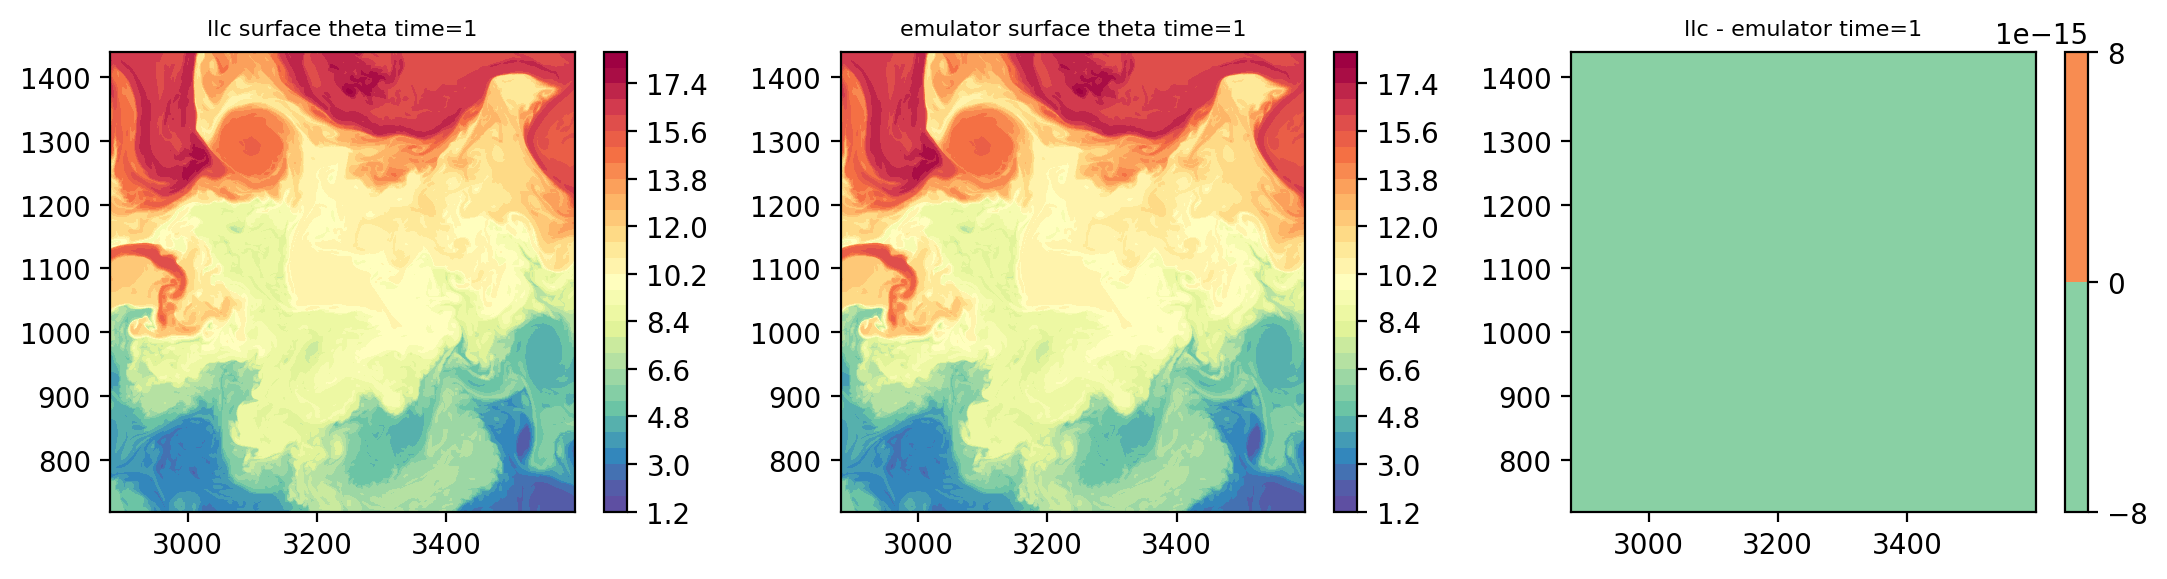

In [4]:
llc_vis = llc_patch.isel(time=1,k=0).Theta
emulator_vis = emulator_patch.isel(time=1,k=0).Theta

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="Spectral_r",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface theta time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="Spectral_r",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface theta time=1', fontsize=8)

diff = llc_vis.values - emulator_vis.values
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="Spectral_r", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
Theta_hist_llc = llc_patch.Theta.stack(vals=['time','i','j']).values
Theta_hist_emulator = emulator_patch.Theta.stack(vals=['time','i','j']).values

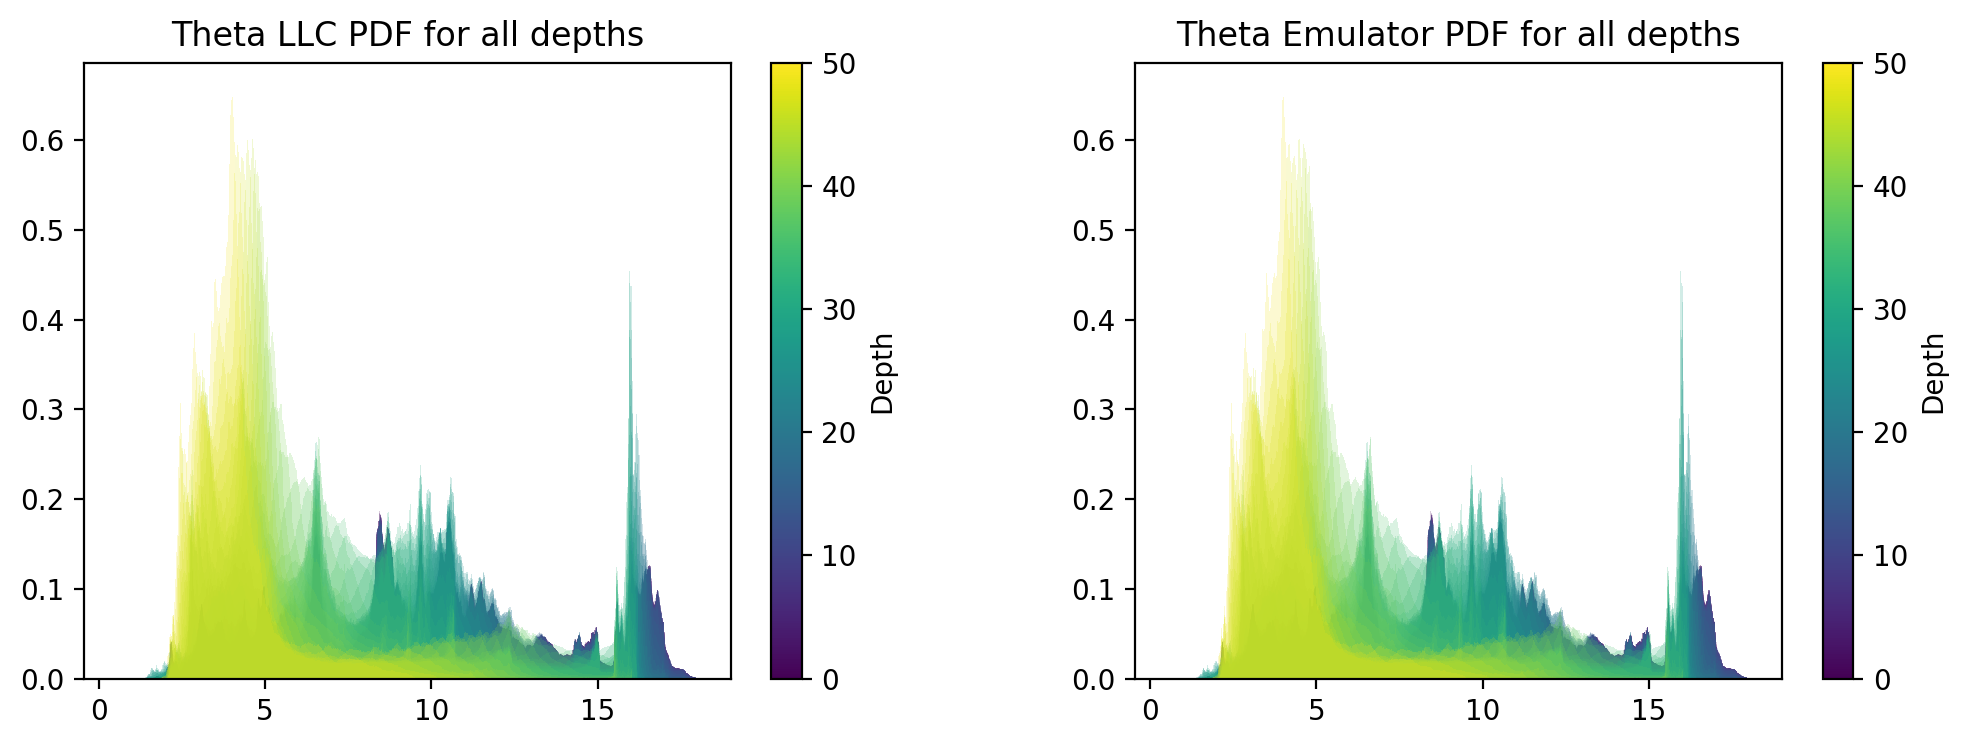

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(Theta_hist_llc)) for i in range(len(Theta_hist_llc))]
for k in range(0,len(Theta_hist_llc)):
    ax1.hist(Theta_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Theta_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('Theta LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(Theta_hist_emulator)) for i in range(len(Theta_hist_emulator))]
for k in range(0,len(Theta_hist_emulator)):
    ax2.hist(Theta_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Theta_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('Theta Emulator PDF for all depths')
plt.tight_layout()
plt.show()

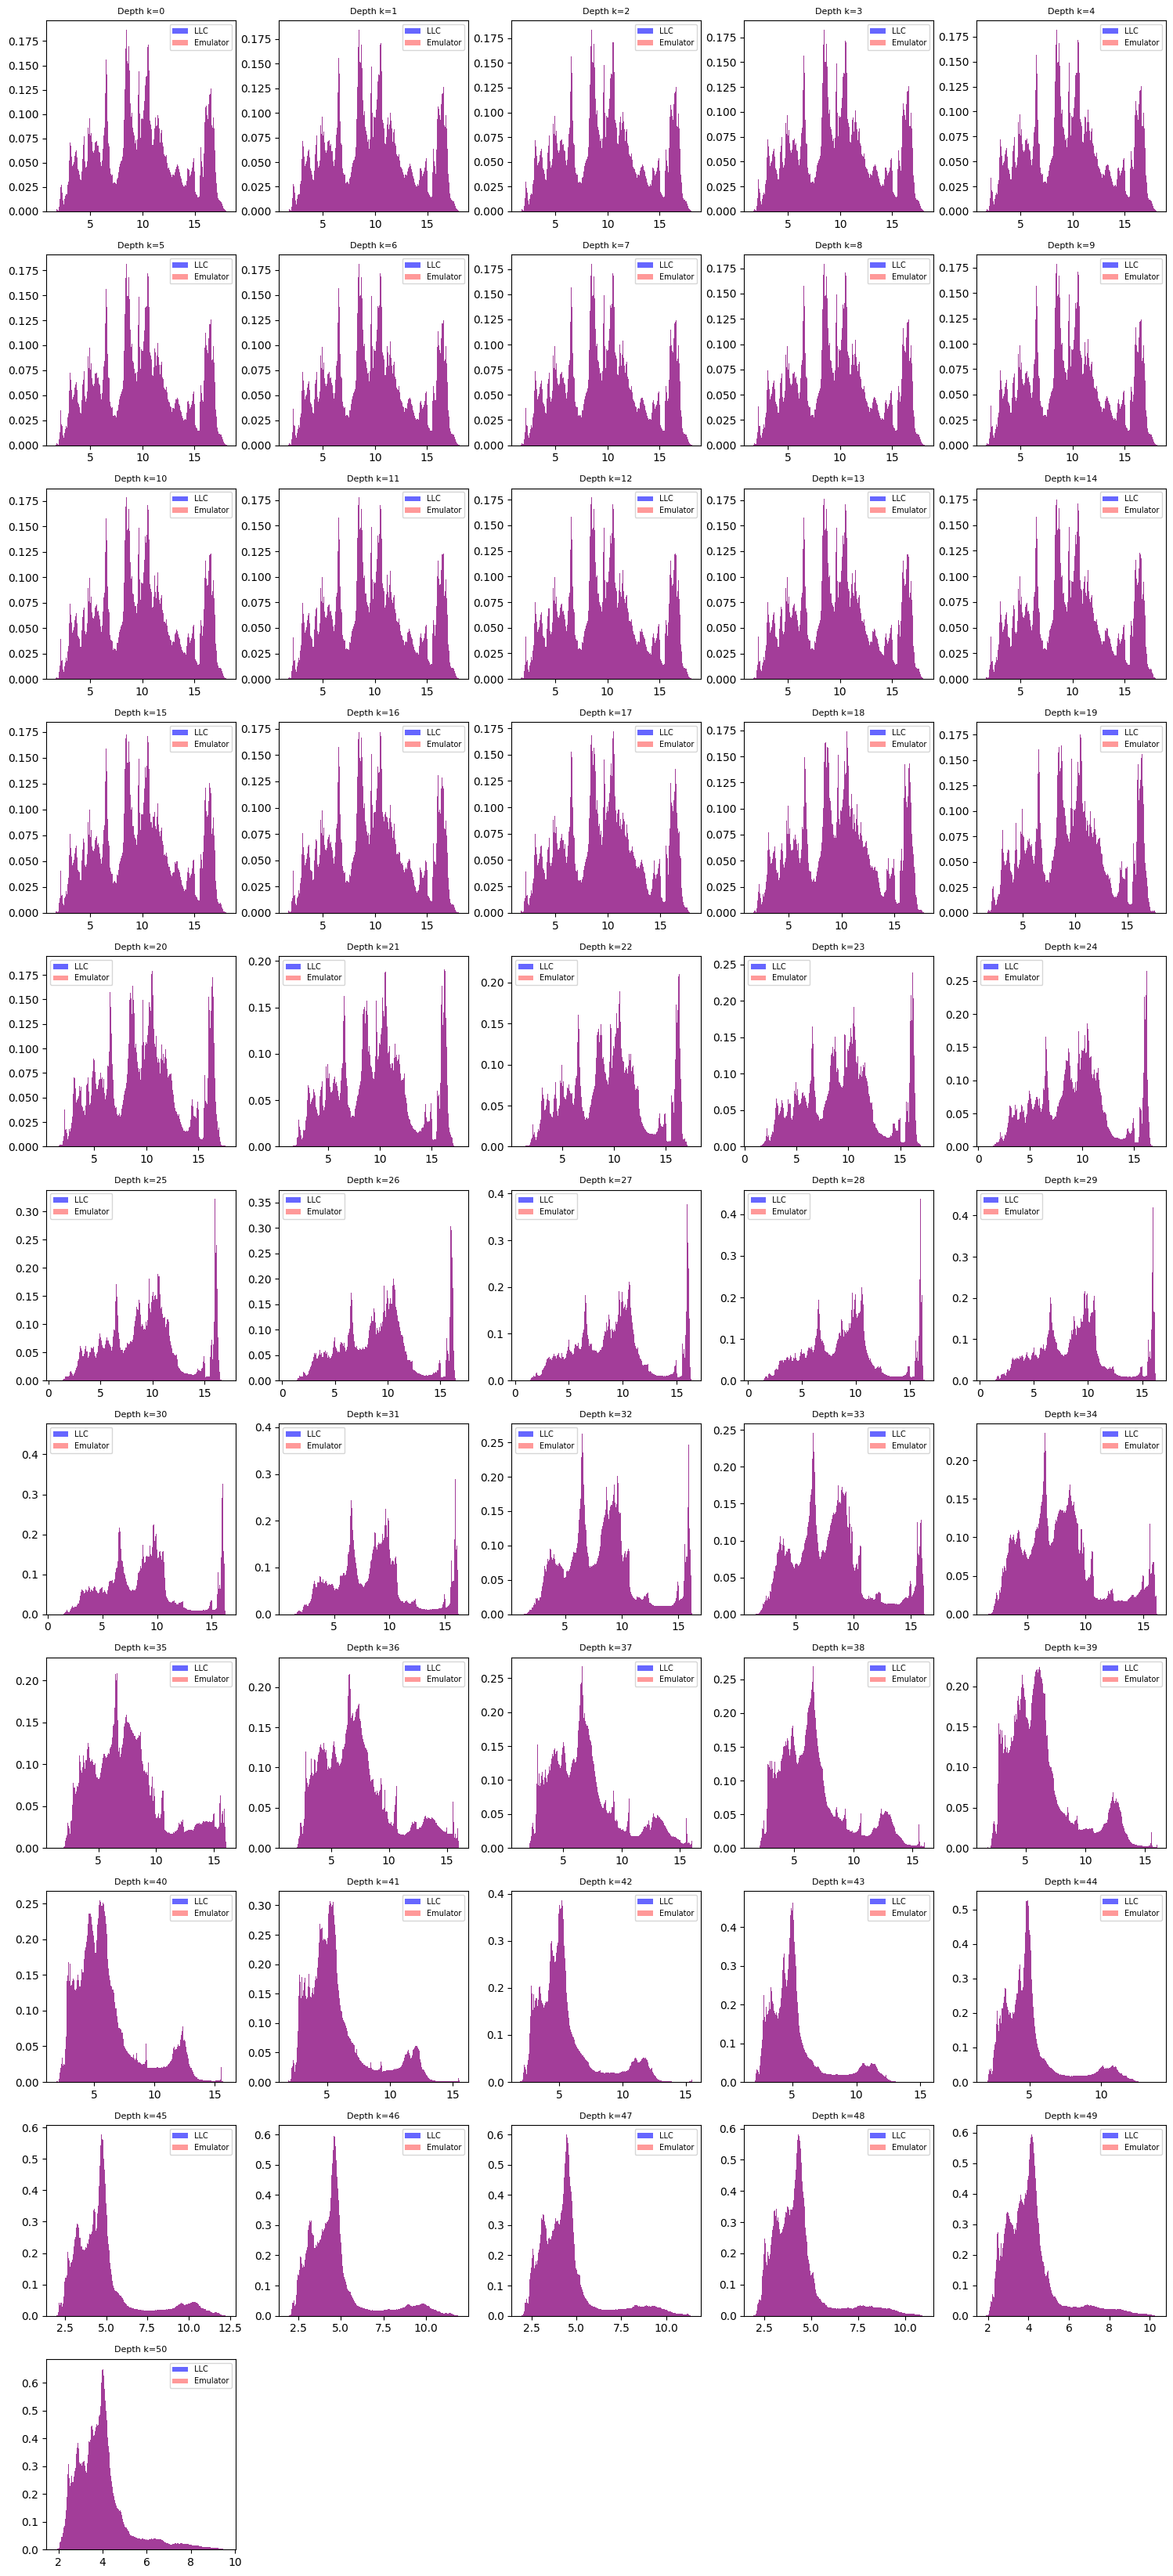

In [10]:
n_depths = len(Theta_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(Theta_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(Theta_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## Salt

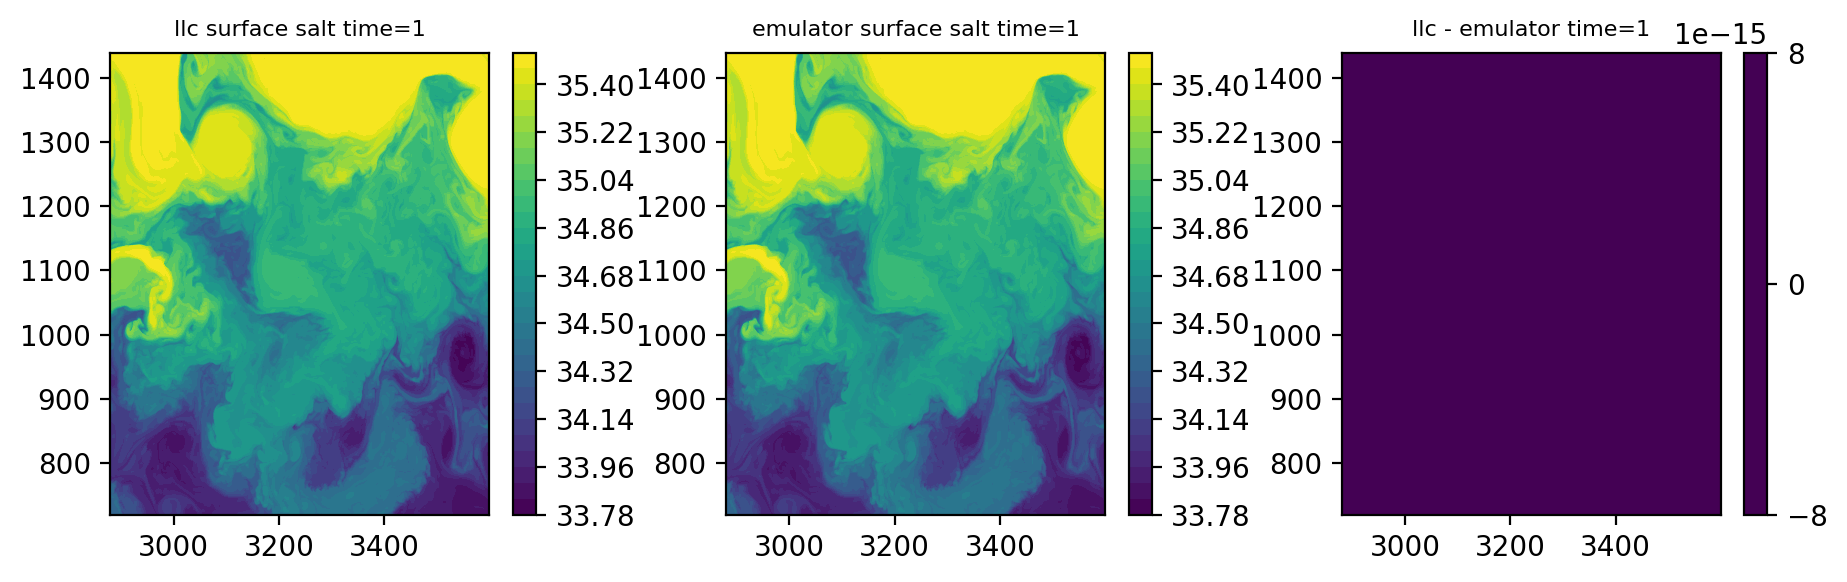

In [ ]:
llc_vis = llc_patch.isel(time=1,k=0).Salt
emulator_vis = emulator_patch.isel(time=1,k=0).Salt

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="viridis",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface salt time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="viridis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface salt time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="viridis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
Salt_hist_llc = llc_patch.Salt.stack(vals=['time','i','j']).values
Salt_hist_emulator = emulator_patch.Salt.stack(vals=['time','i','j']).values

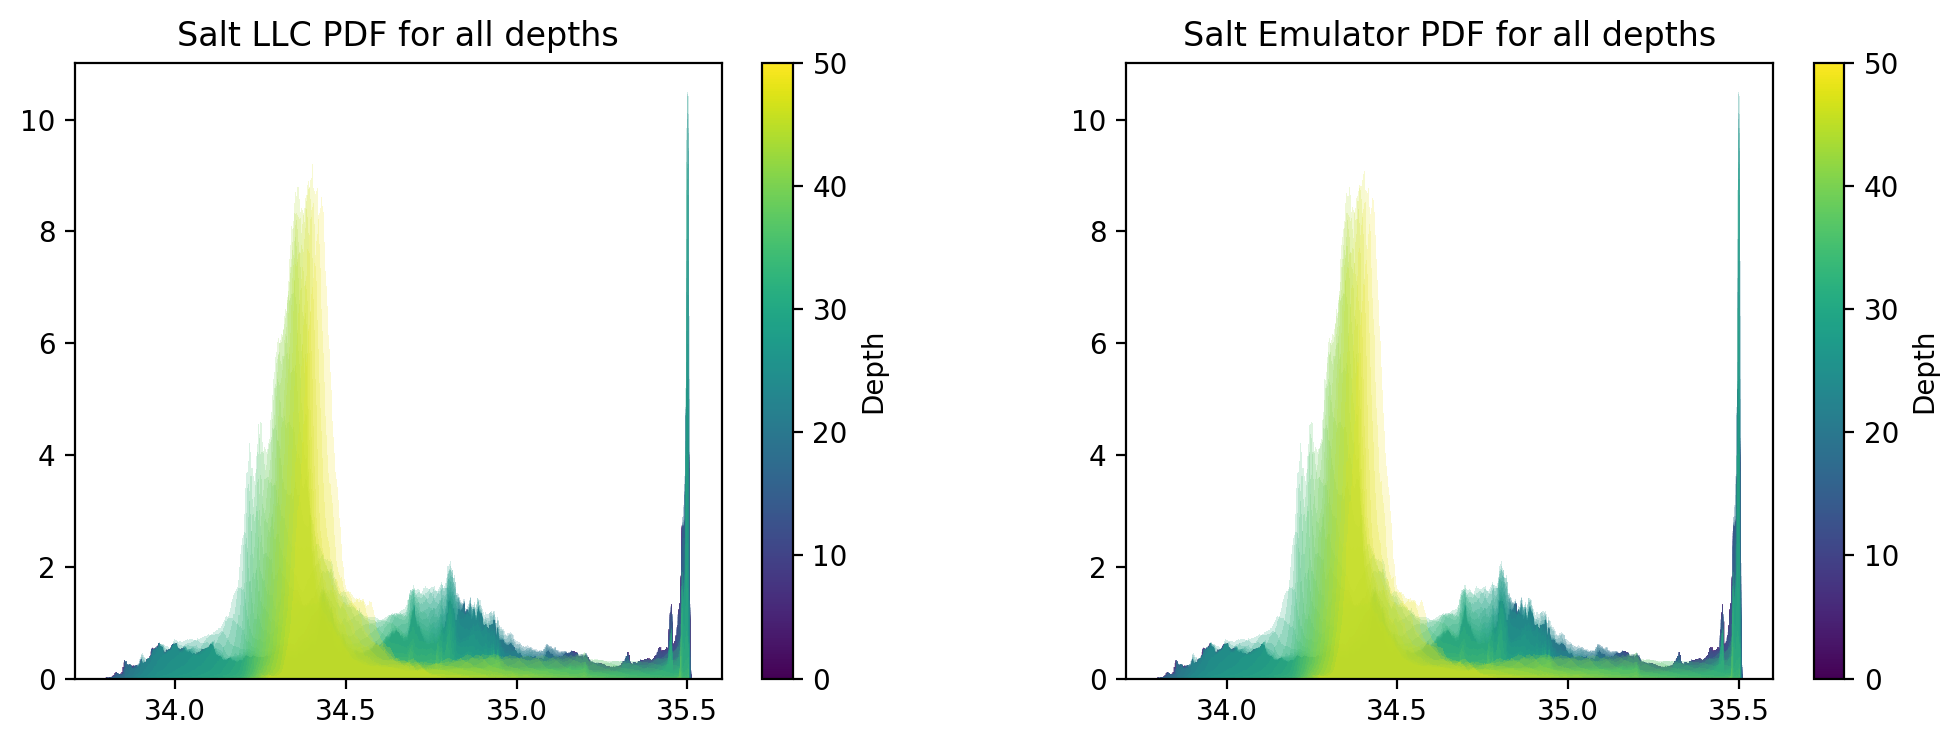

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(Salt_hist_llc)) for i in range(len(Salt_hist_llc))]
for k in range(0,len(Salt_hist_llc)):
    ax1.hist(Salt_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('Salt LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(Salt_hist_emulator)) for i in range(len(Salt_hist_emulator))]
for k in range(0,len(Salt_hist_emulator)):
    ax2.hist(Salt_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(Salt_hist_emulator)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('Salt Emulator PDF for all depths')
plt.tight_layout()
plt.show()

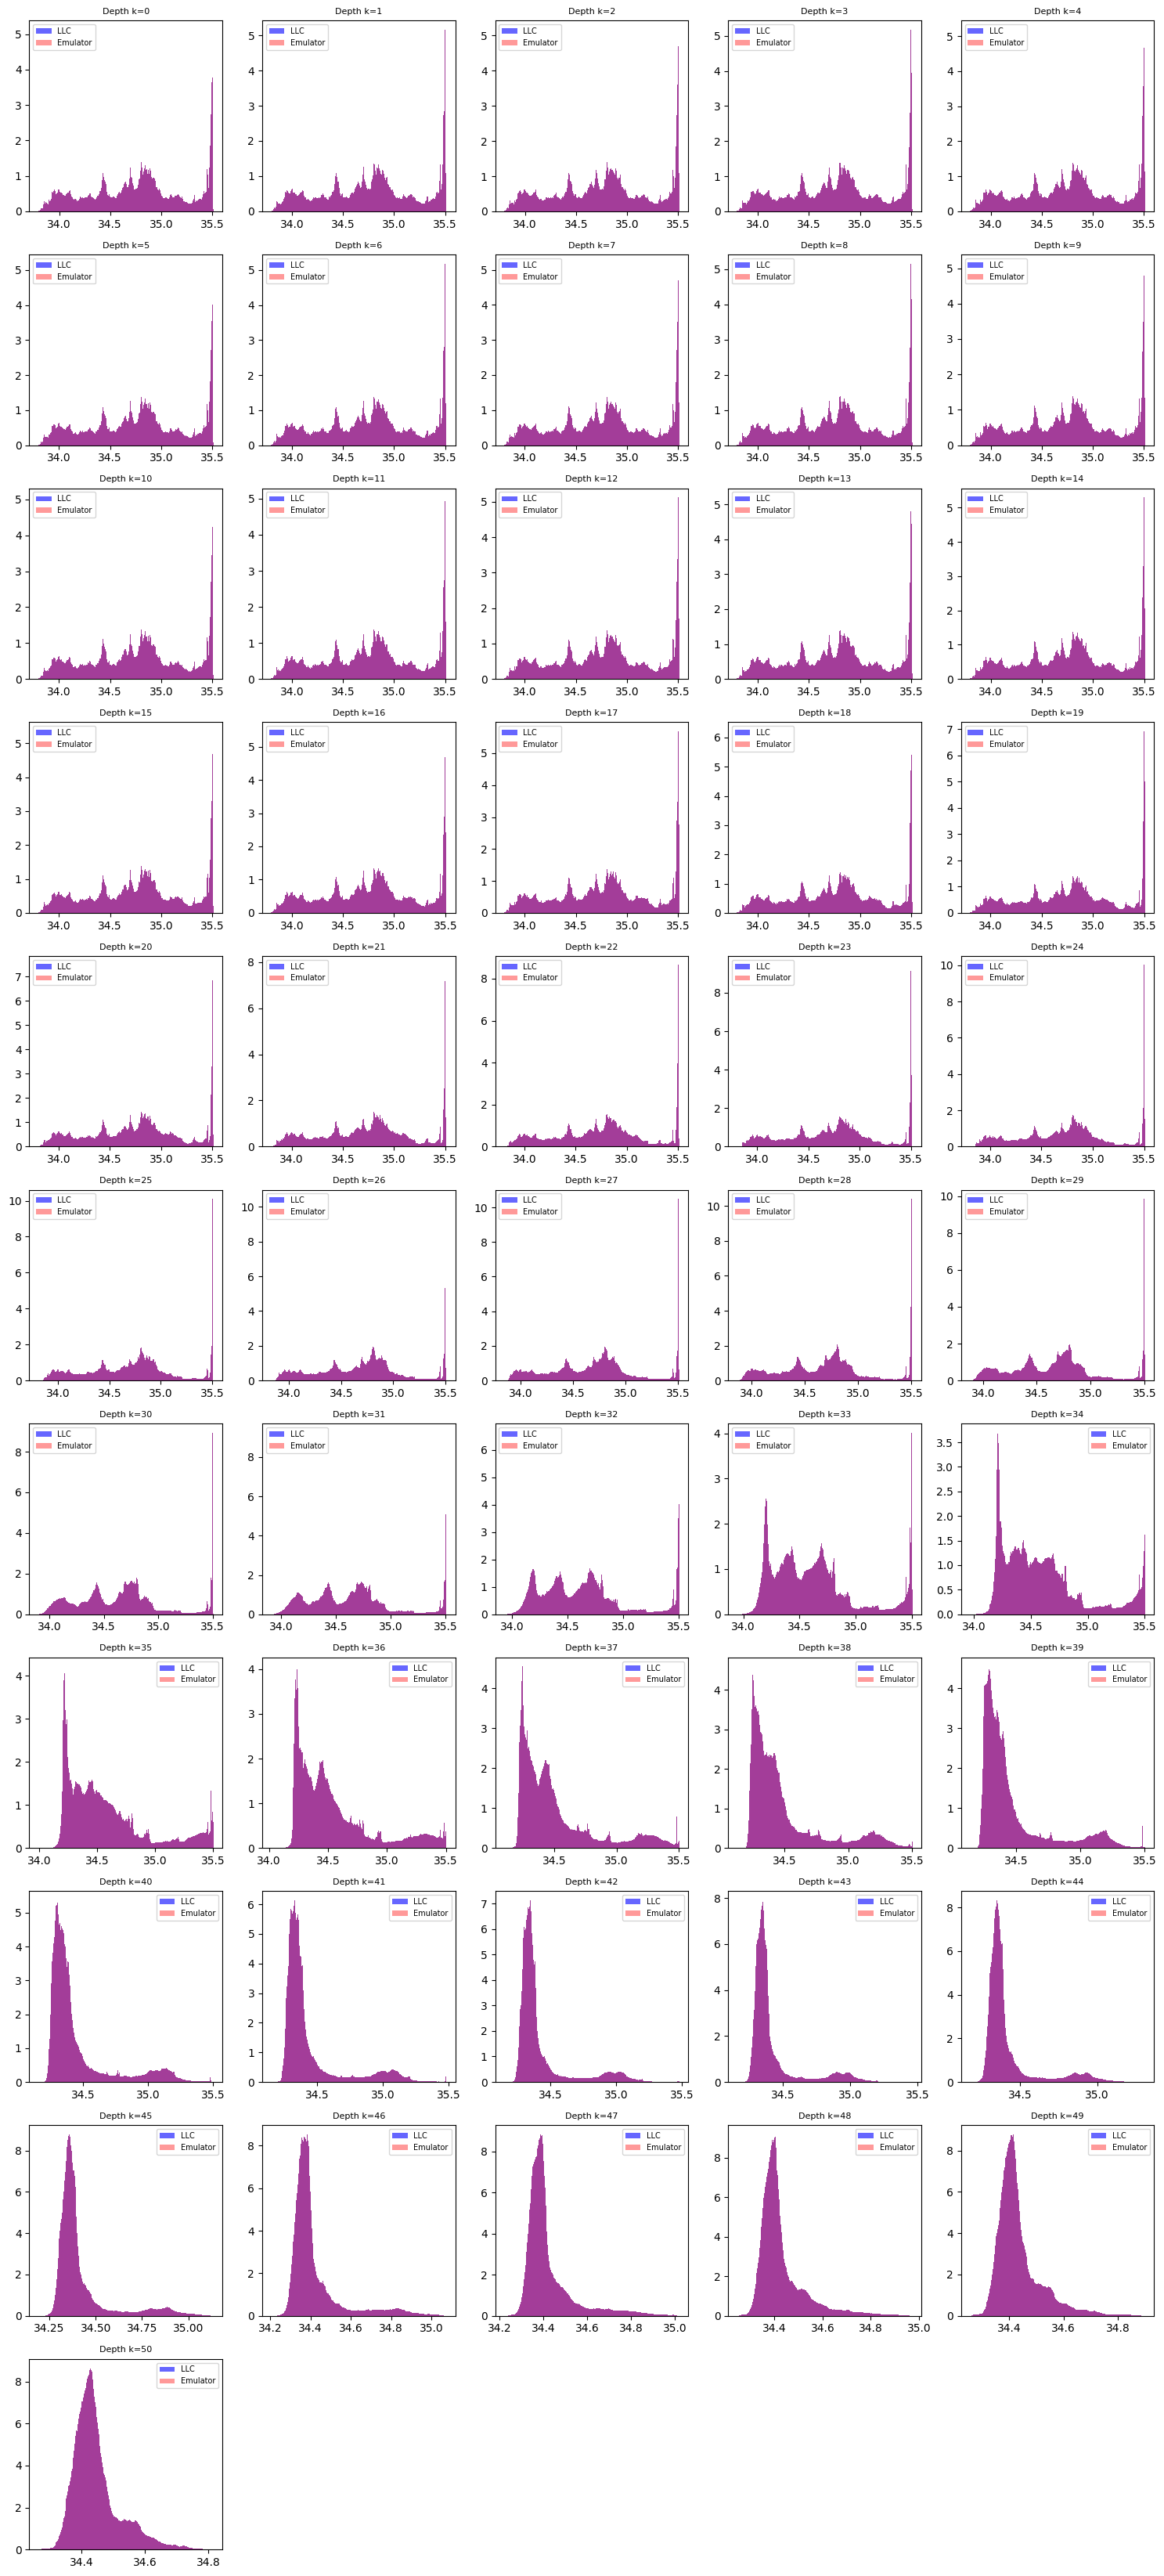

In [ ]:
n_depths = len(Salt_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(Salt_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(Salt_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## U, V

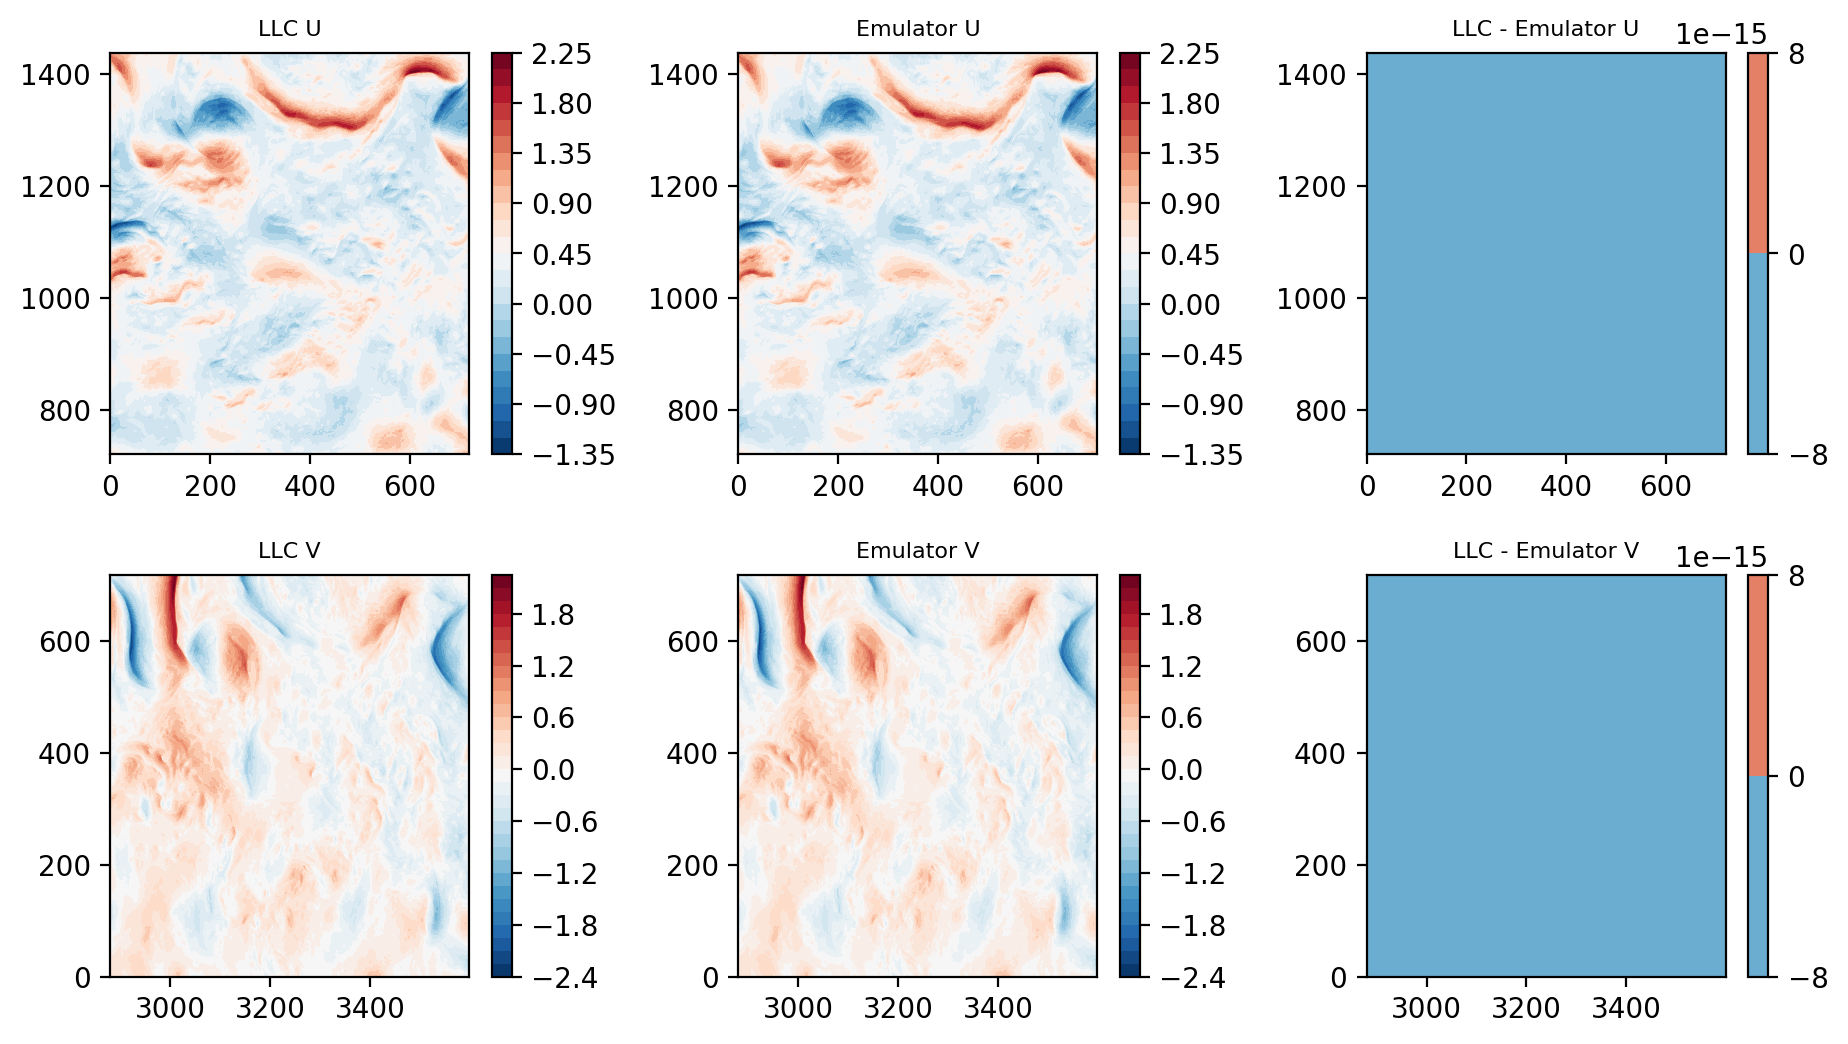

In [ ]:
llc_vis_U = llc_patch.isel(time=1,k=0).U
emulator_vis_U = emulator_patch.isel(time=1,k=0).U
llc_vis_V = llc_patch.isel(time=1,k=0).V
emulator_vis_V = emulator_patch.isel(time=1,k=0).V

fig, axes = plt.subplots(2, 3, figsize=(11, 6), dpi=200)

# Row 1: U
cf1 = axes[0,0].contourf(llc_vis_U.coords.get('i', np.arange(llc_vis_U.shape[-1])), 
    llc_vis_U.coords.get('j', np.arange(llc_vis_U.shape[-2])), llc_vis_U, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf1, ax=axes[0,0])
axes[0,0].set_title('LLC U', fontsize=8)

cf2 = axes[0,1].contourf(emulator_vis_U.coords.get('i', np.arange(emulator_vis_U.shape[-1])), 
    emulator_vis_U.coords.get('j', np.arange(emulator_vis_U.shape[-2])), emulator_vis_U, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf2, ax=axes[0,1])
axes[0,1].set_title('Emulator U', fontsize=8)

cf3 = axes[0,2].contourf(emulator_vis_U.coords.get('i', np.arange(emulator_vis_U.shape[-1])), 
    emulator_vis_U.coords.get('j', np.arange(emulator_vis_U.shape[-2])), llc_vis_U - emulator_vis_U, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf3, ax=axes[0,2])
axes[0,2].set_title('LLC - Emulator U', fontsize=8)

# Row 2: V
cf4 = axes[1,0].contourf(llc_vis_V.coords.get('i', np.arange(llc_vis_V.shape[-1])), 
    llc_vis_V.coords.get('j', np.arange(llc_vis_V.shape[-2])), llc_vis_V, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf4, ax=axes[1,0])
axes[1,0].set_title('LLC V', fontsize=8)

cf5 = axes[1,1].contourf(emulator_vis_V.coords.get('i', np.arange(emulator_vis_V.shape[-1])), 
    emulator_vis_V.coords.get('j', np.arange(emulator_vis_V.shape[-2])), emulator_vis_V, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf5, ax=axes[1,1])
axes[1,1].set_title('Emulator V', fontsize=8)

cf6 = axes[1,2].contourf(emulator_vis_V.coords.get('i', np.arange(emulator_vis_V.shape[-1])), 
    emulator_vis_V.coords.get('j', np.arange(emulator_vis_V.shape[-2])), llc_vis_V - emulator_vis_V, 
    cmap="RdBu_r", levels=30)
plt.colorbar(cf6, ax=axes[1,2])
axes[1,2].set_title('LLC - Emulator V', fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
U_hist_llc = llc_patch.U.stack(vals=['time','i_g','j']).values
U_hist_emulator = emulator_patch.U.stack(vals=['time','i_g','j']).values

V_hist_llc = llc_patch.V.stack(vals=['time','i','j_g']).values
V_hist_emulator = emulator_patch.V.stack(vals=['time','i','j_g']).values

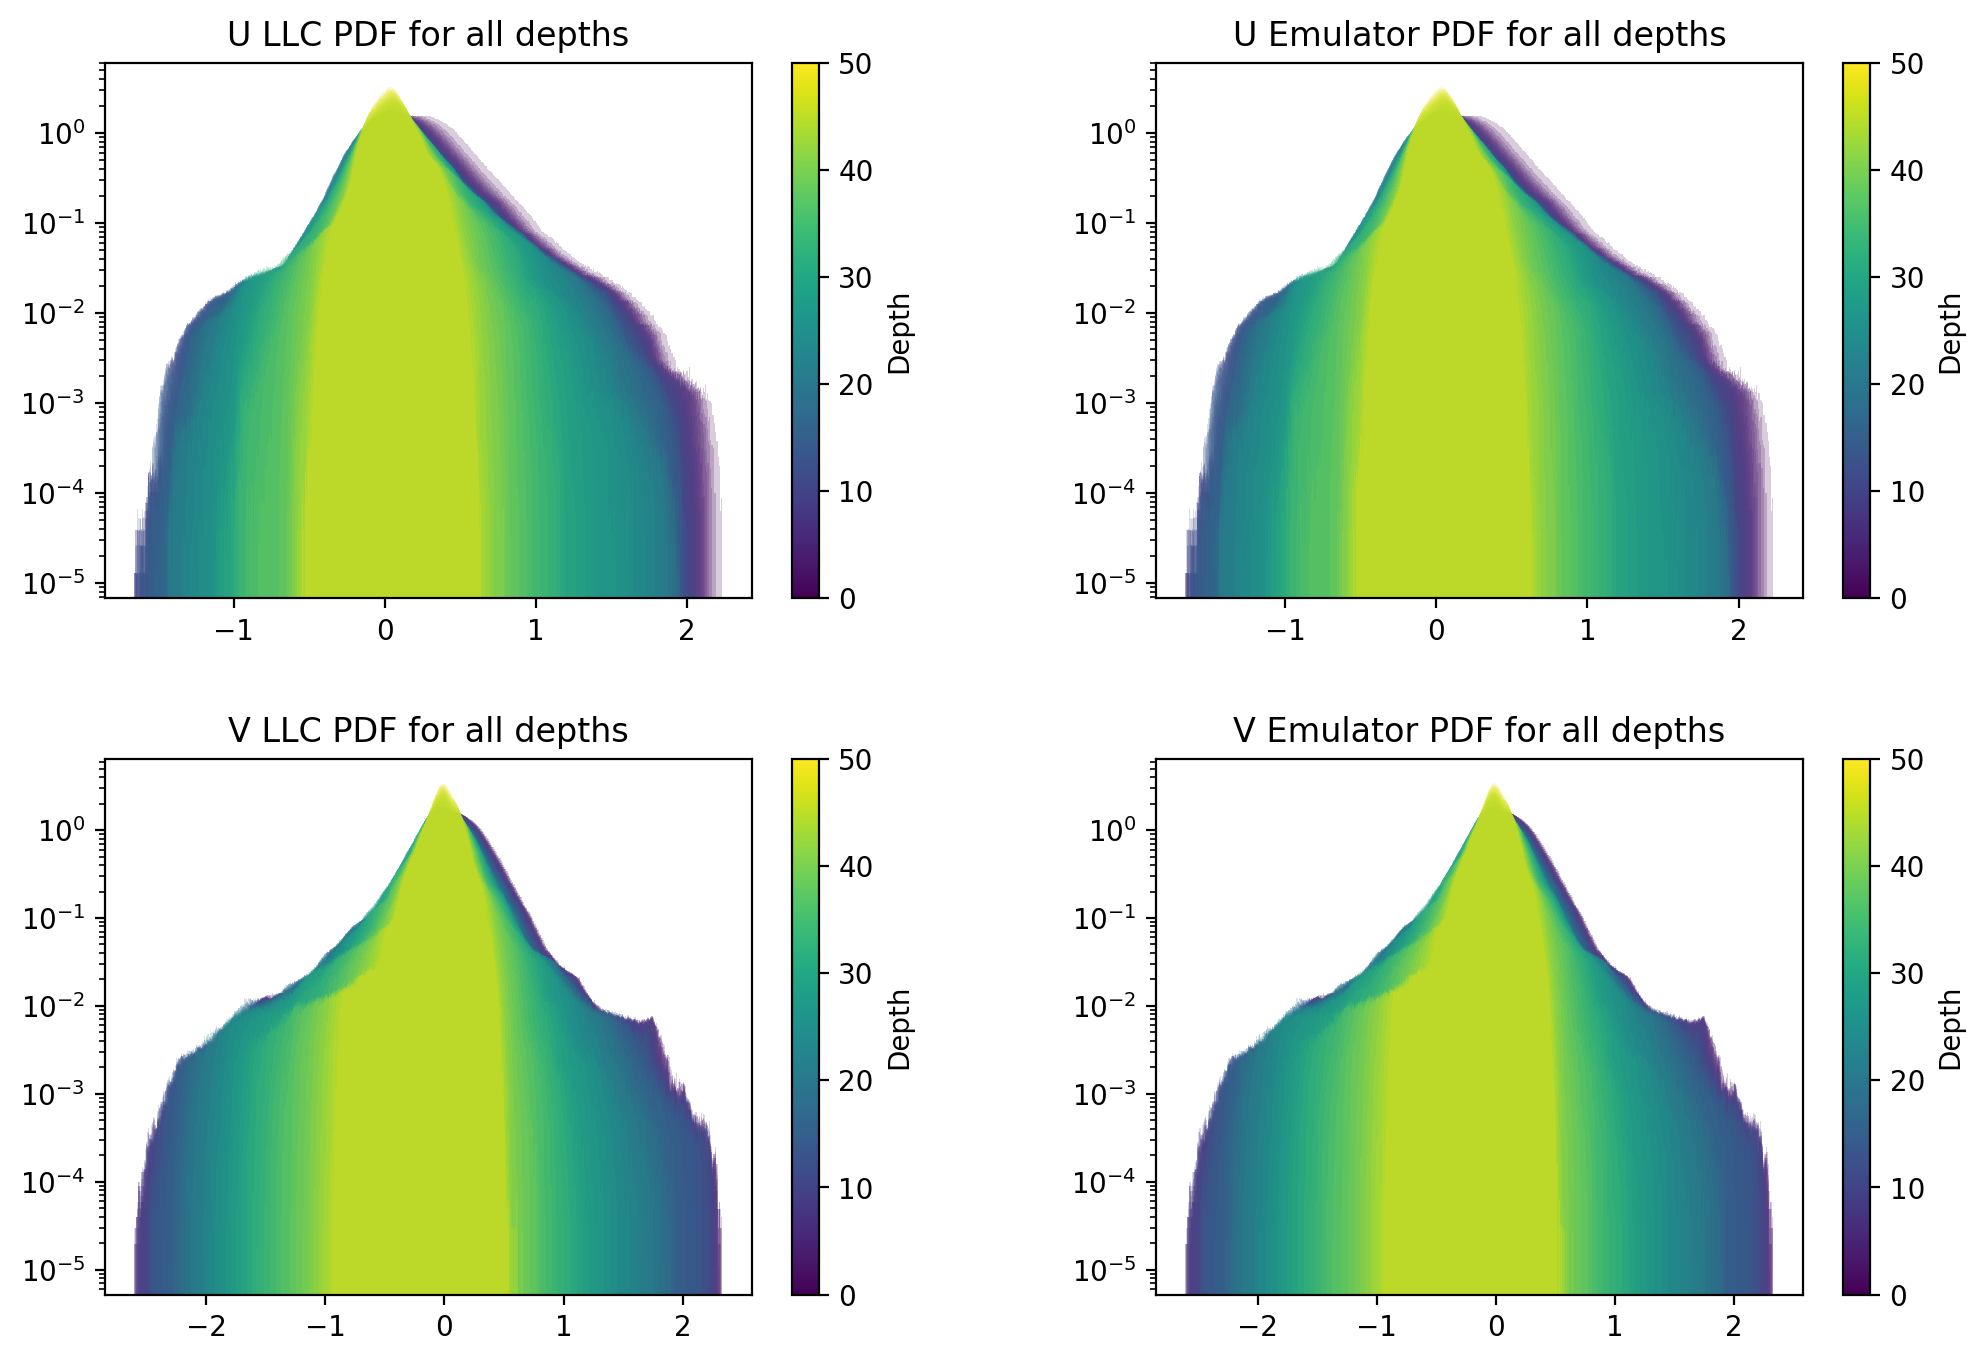

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=200)

# U LLC
cm = [plt.cm.viridis(i/len(U_hist_llc)) for i in range(len(U_hist_llc))]
for k in range(0, len(U_hist_llc)):
    axes[0,0].hist(U_hist_llc[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[0,0].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(U_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[0,0])
axes[0,0].set_title('U LLC PDF for all depths')

# U Emulator
cm = [plt.cm.viridis(i/len(U_hist_emulator)) for i in range(len(U_hist_emulator))]
for k in range(0, len(U_hist_emulator)):
    axes[0,1].hist(U_hist_emulator[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[0,1].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(U_hist_emulator)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[0,1])
axes[0,1].set_title('U Emulator PDF for all depths')

# V LLC
cm = [plt.cm.viridis(i/len(V_hist_llc)) for i in range(len(V_hist_llc))]
for k in range(0, len(V_hist_llc)):
    axes[1,0].hist(V_hist_llc[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[1,0].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(V_hist_llc)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[1,0])
axes[1,0].set_title('V LLC PDF for all depths')

# V Emulator
cm = [plt.cm.viridis(i/len(V_hist_emulator)) for i in range(len(V_hist_emulator))]
for k in range(0, len(V_hist_emulator)):
    axes[1,1].hist(V_hist_emulator[k], bins=500, density=True, color=cm[k], alpha=0.2)
axes[1,1].set_yscale('log')
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(V_hist_emulator)-1))
sm.set_array([])
plt.colorbar(sm, label='Depth', ax=axes[1,1])
axes[1,1].set_title('V Emulator PDF for all depths')

plt.tight_layout()
plt.show()

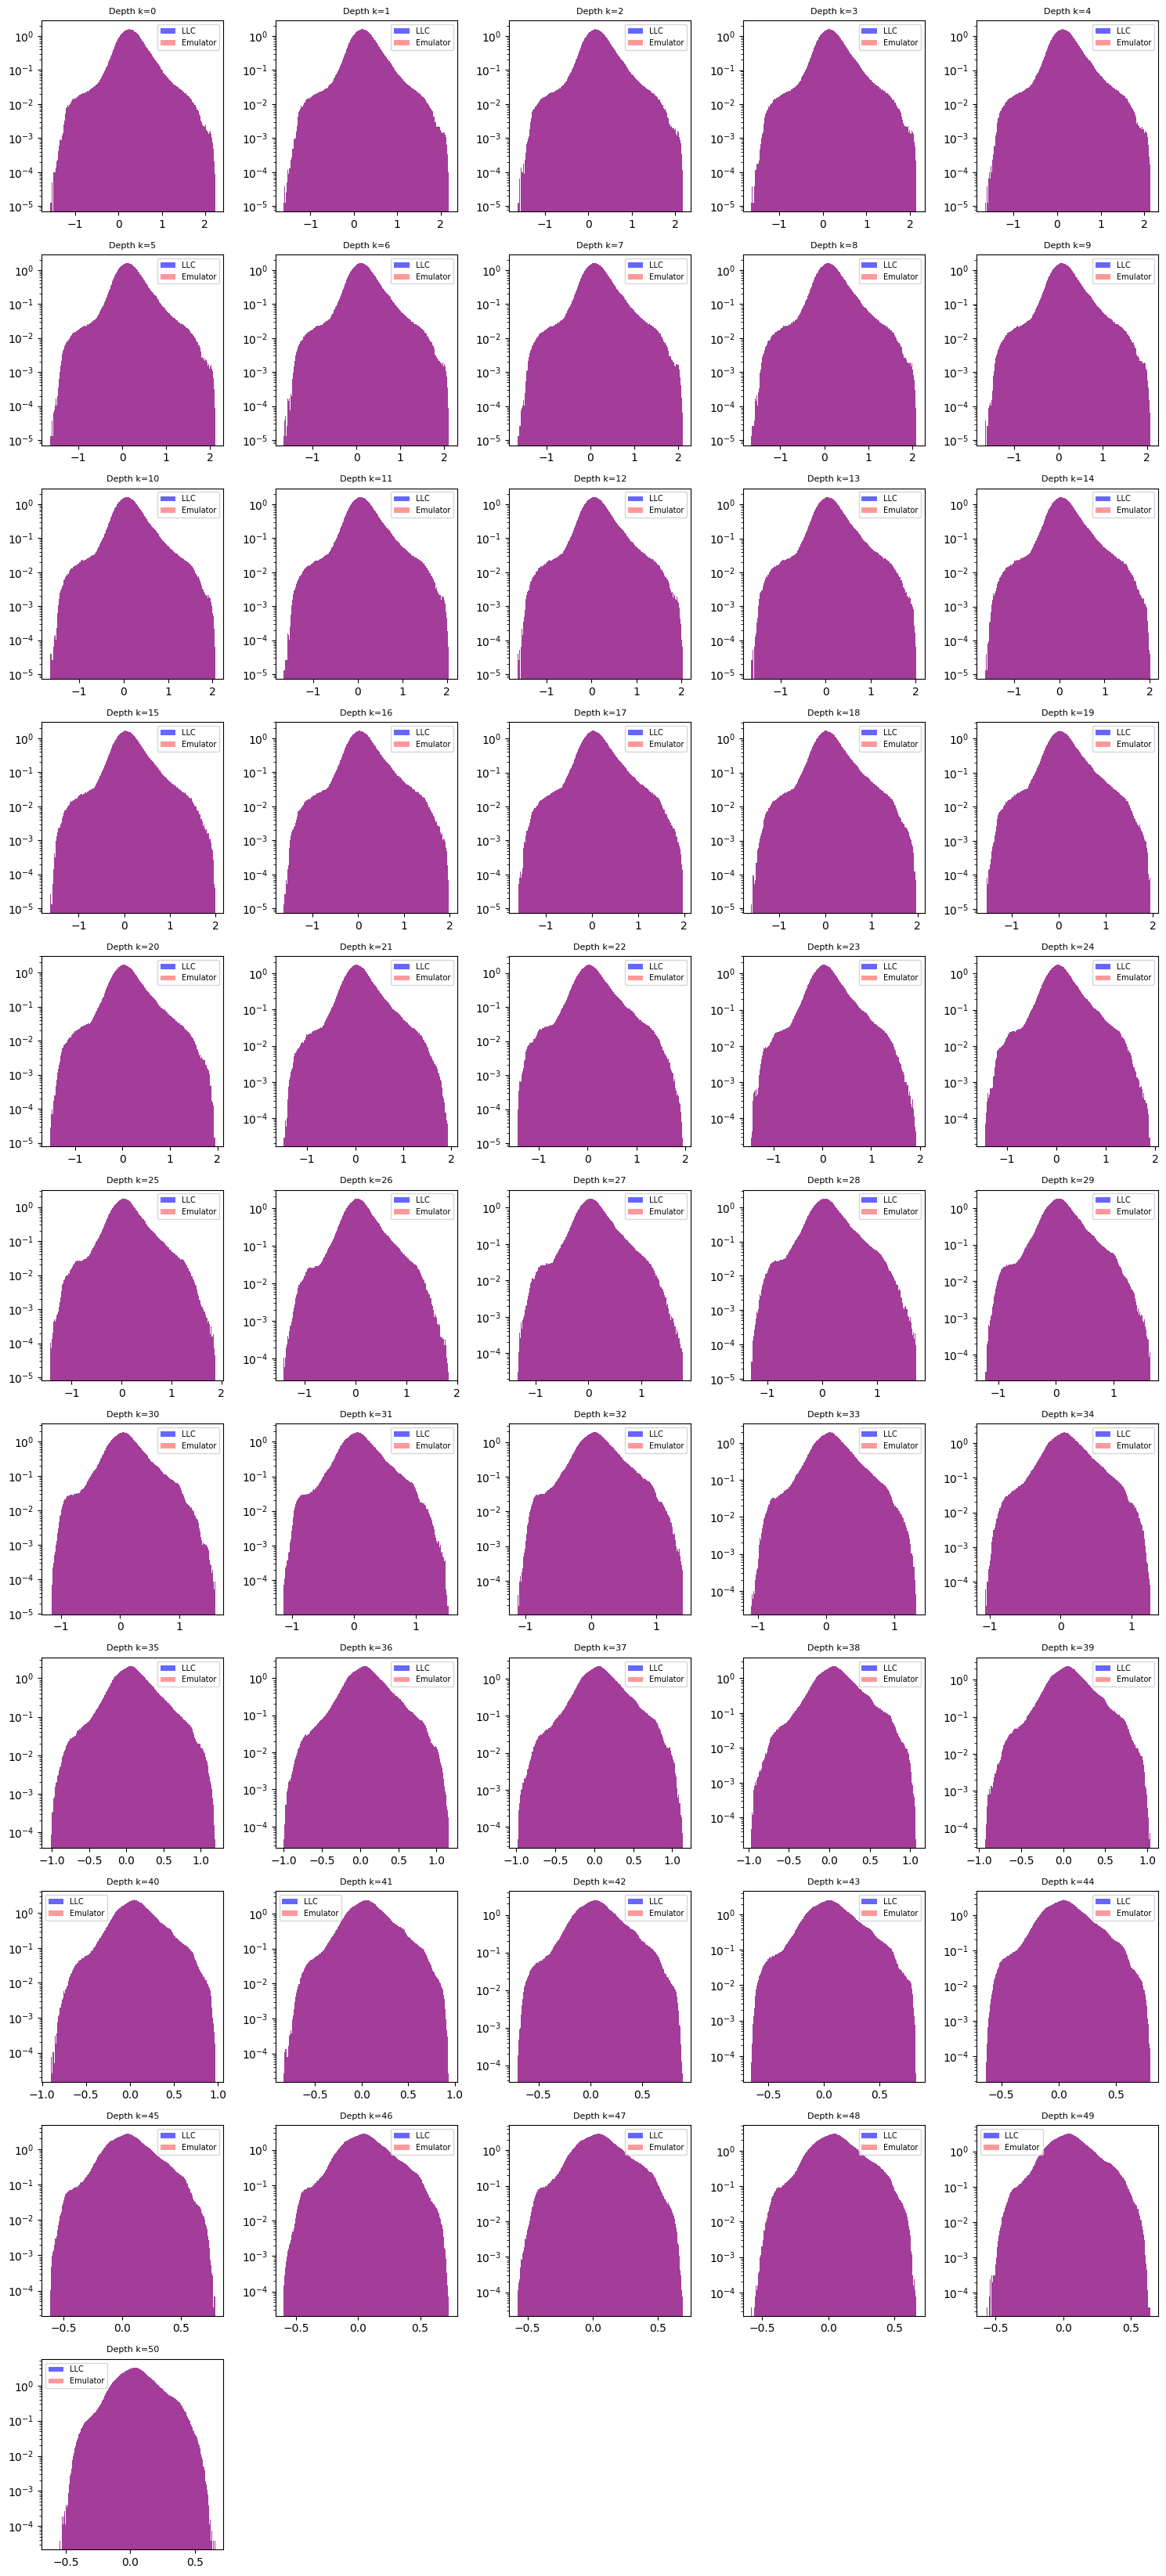

In [18]:
n_depths = len(U_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(U_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(U_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_yscale('log')

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

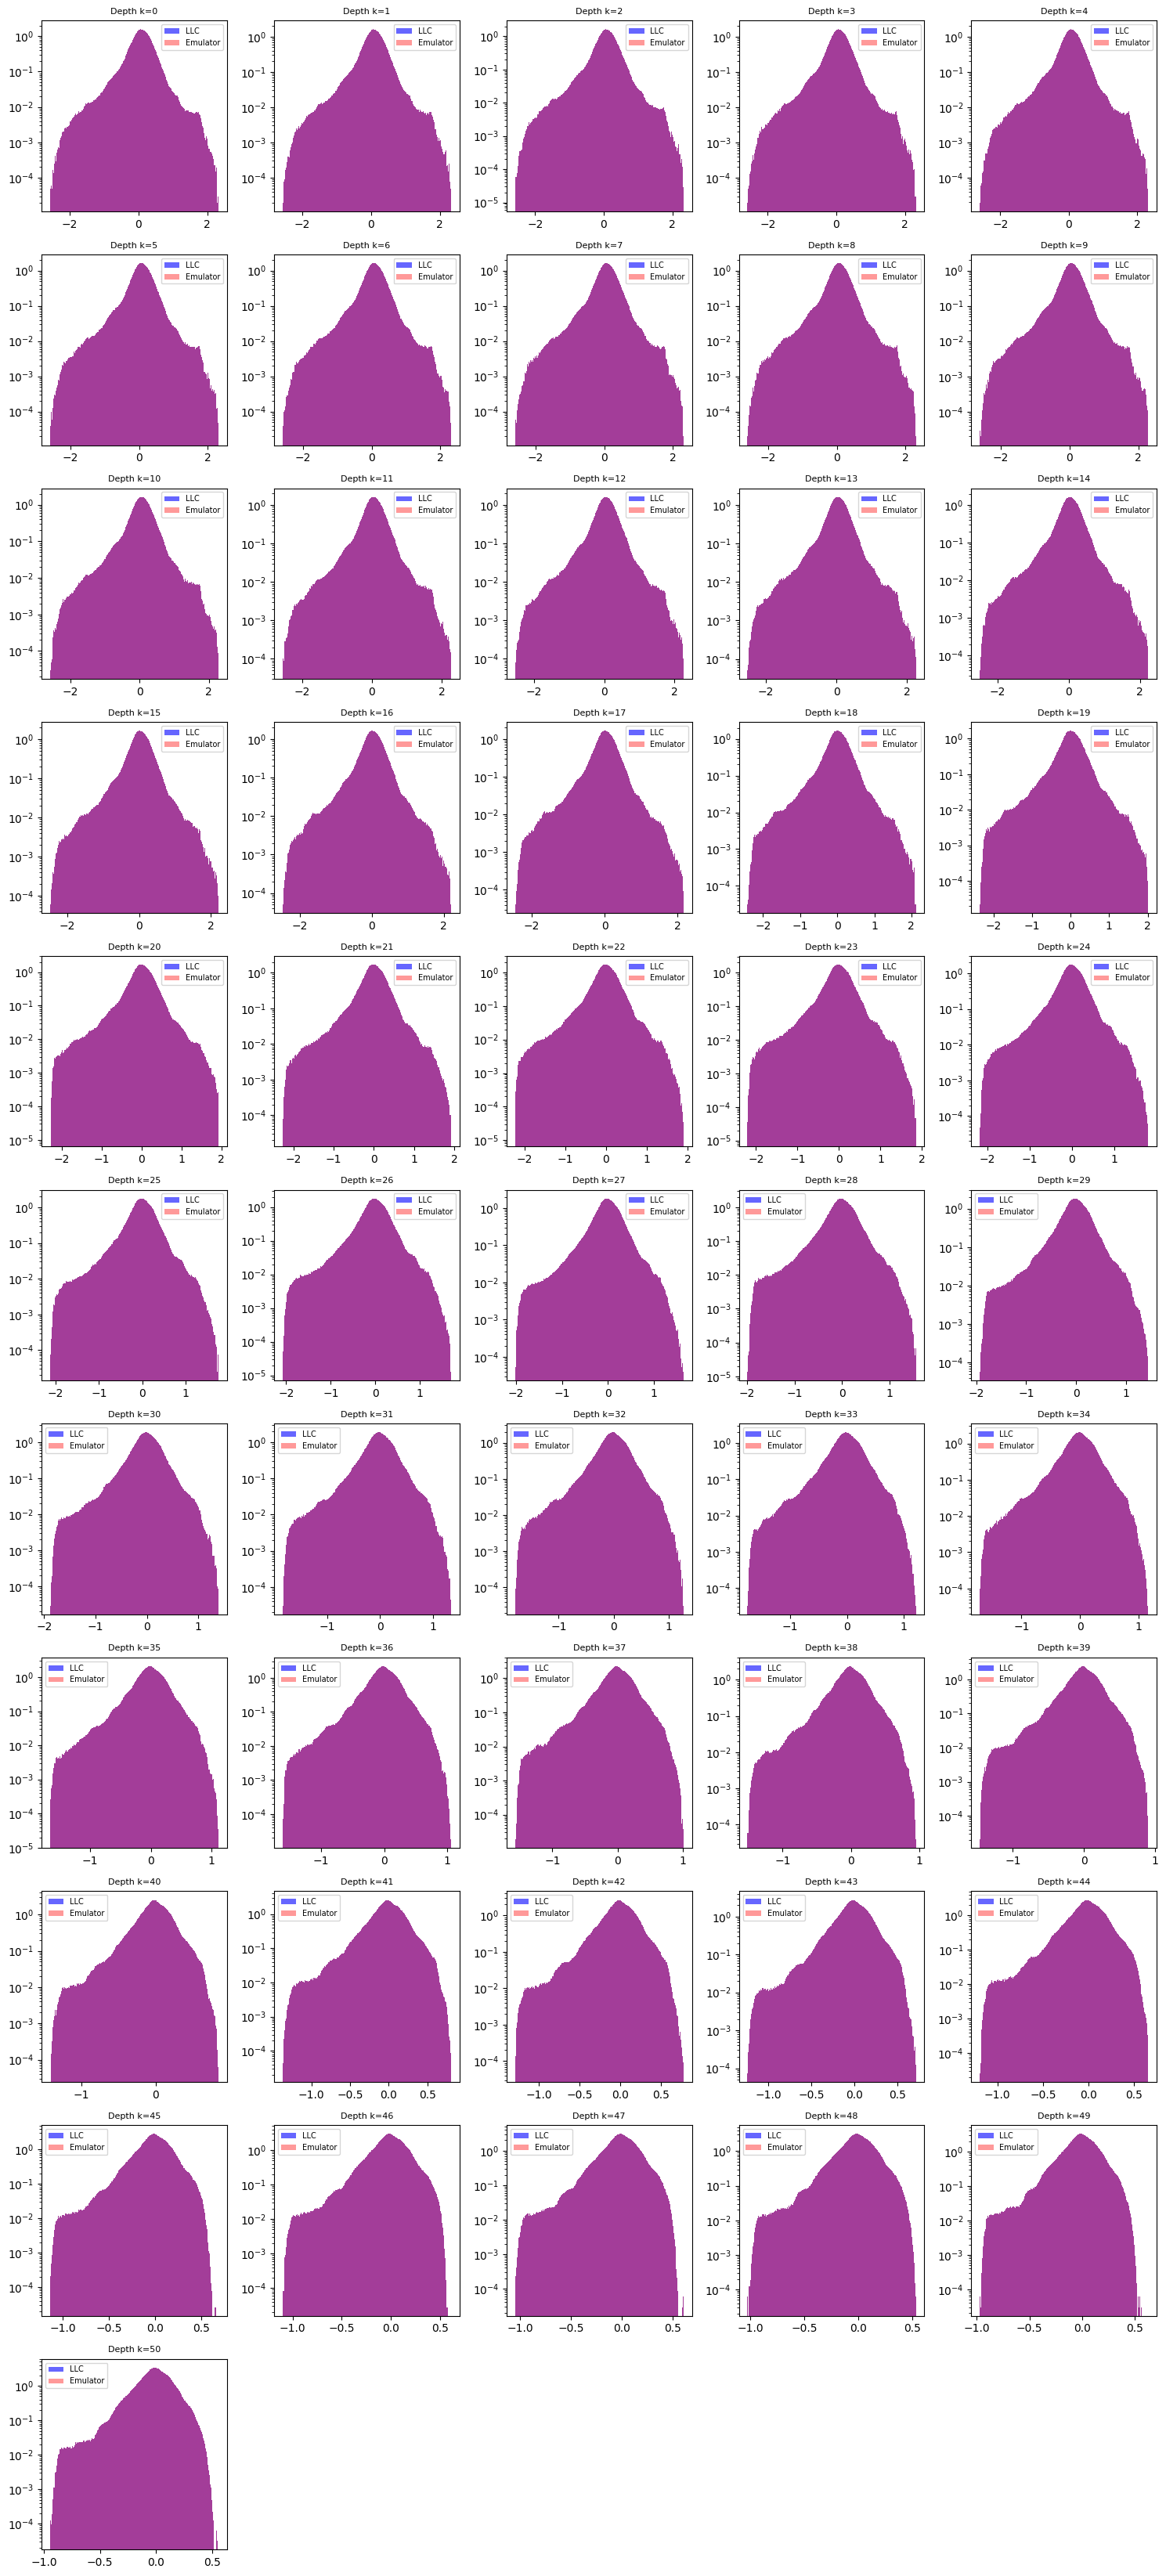

In [19]:
n_depths = len(V_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(V_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(V_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.legend(fontsize=7)
    ax.set_yscale('log')

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## Shear

In [5]:
# LLC Patch
dz_llc = np.diff(llc_patch.Z.values)
dz_llc = dz_llc[np.newaxis, :, np.newaxis, np.newaxis]

du_dz_llc = np.diff(llc_patch['U'].values, axis=1) / dz_llc
dv_dz_llc = np.diff(llc_patch['V'].values, axis=1) / dz_llc

S2_llc = du_dz_llc**2 + dv_dz_llc**2

llc_patch['S2'] = xr.DataArray(S2_llc, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

In [6]:
# Emulator Patch
dz_emulator = np.diff(emulator_patch.Z.values)
dz_emulator = dz_emulator[np.newaxis, :, np.newaxis, np.newaxis]

du_dz_emulator = np.diff(emulator_patch['U'].values, axis=1) / dz_emulator
dv_dz_emulator = np.diff(emulator_patch['V'].values, axis=1) / dz_emulator

S2_emulator = du_dz_emulator**2 + dv_dz_emulator**2

emulator_patch['S2'] = xr.DataArray(S2_emulator, dims=['time', 'k', 'j', 'i'], 
                                    coords={'time': emulator_patch['time'], 'k': emulator_patch['k'][:-1],
                                            'j': emulator_patch['j'], 'i': emulator_patch['i']})

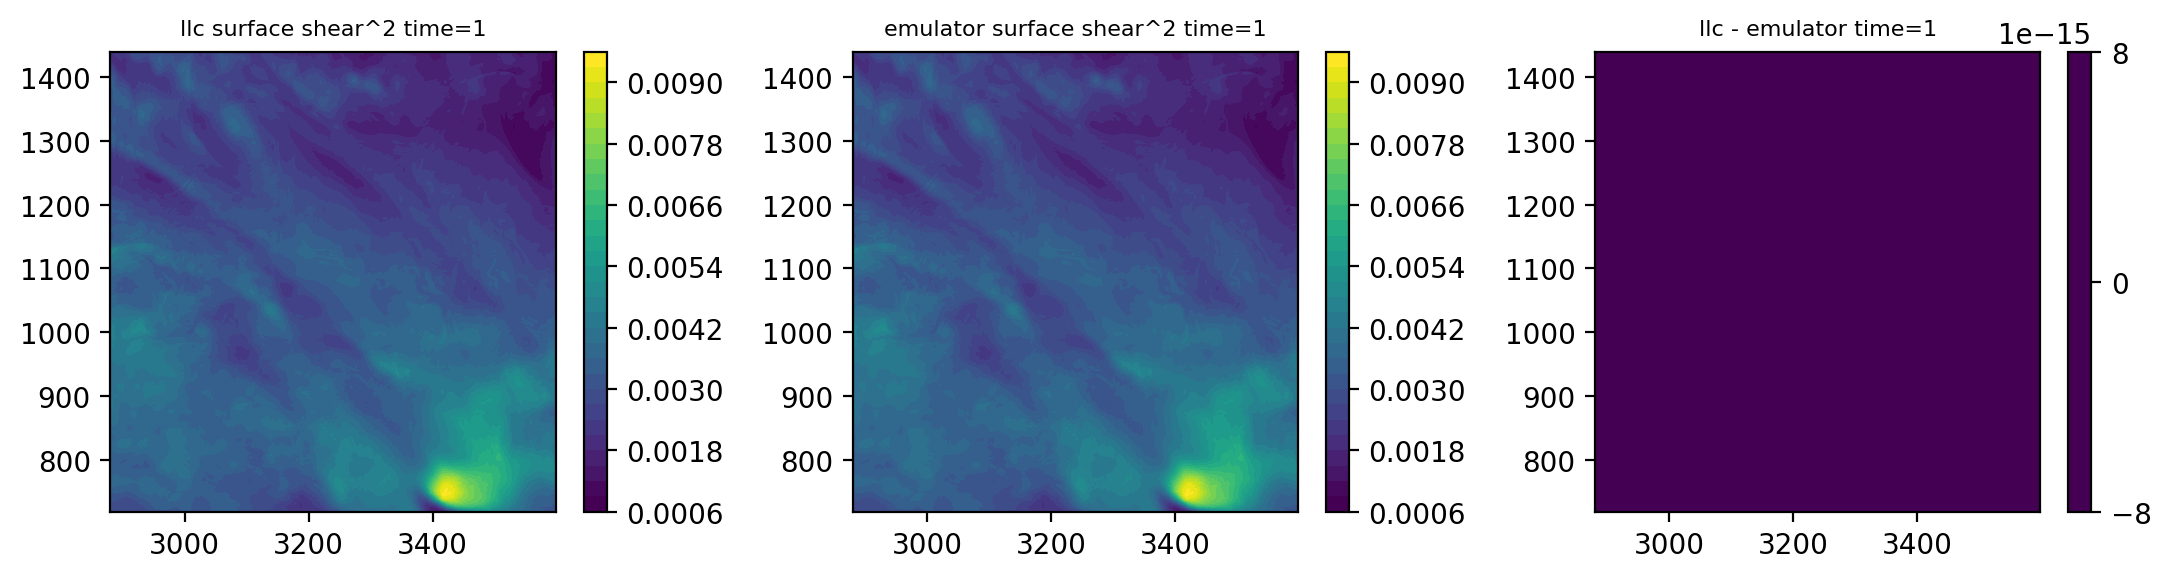

In [7]:
llc_vis = llc_patch.isel(time=1,k=0).S2
emulator_vis = emulator_patch.isel(time=1,k=0).S2

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="viridis",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface shear^2 time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="viridis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface shear^2 time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="viridis",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [10]:
S2_hist_llc = llc_patch.S2.stack(vals=['time','i','j']).values[:-1]
S2_hist_emulator = emulator_patch.S2.stack(vals=['time','i','j']).values[:-1]

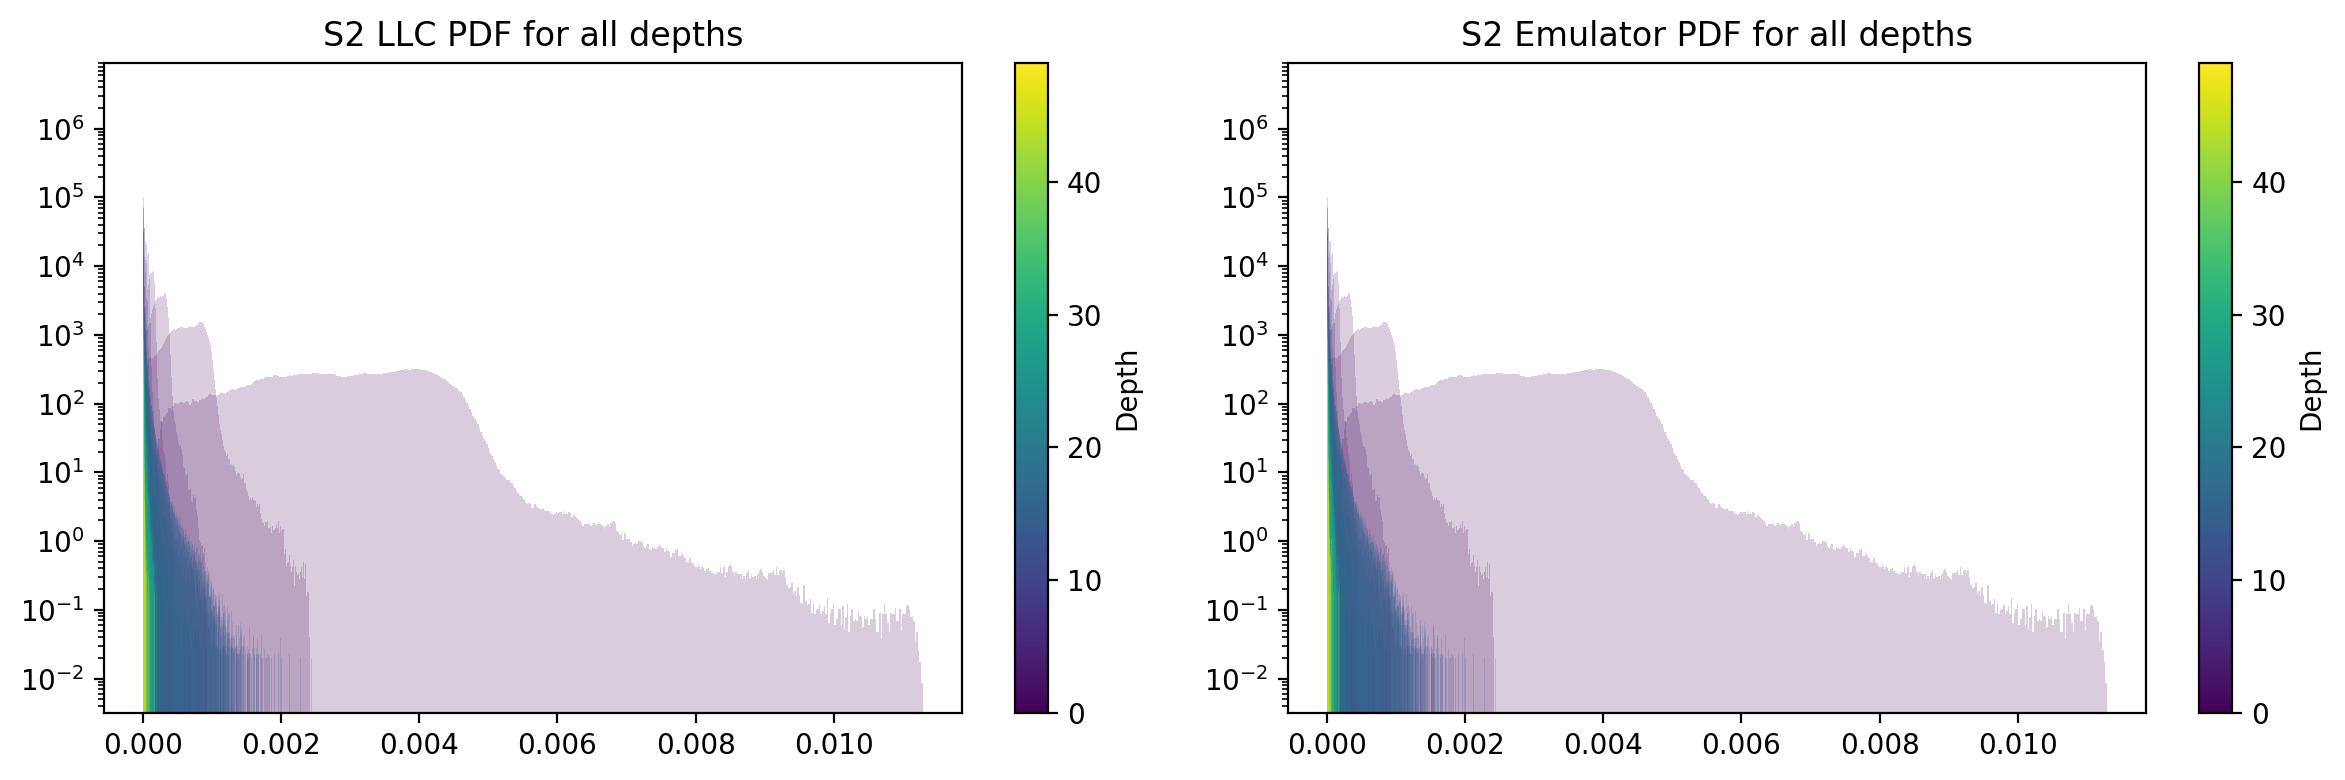

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(S2_hist_llc)) for i in range(len(S2_hist_llc))]
for k in range(0,len(S2_hist_llc)):
    ax1.hist(S2_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(S2_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('S2 LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(S2_hist_emulator)) for i in range(len(S2_hist_emulator))]
for k in range(0,len(S2_hist_emulator)):
    ax2.hist(S2_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(S2_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('S2 Emulator PDF for all depths')
plt.tight_layout()
plt.show()

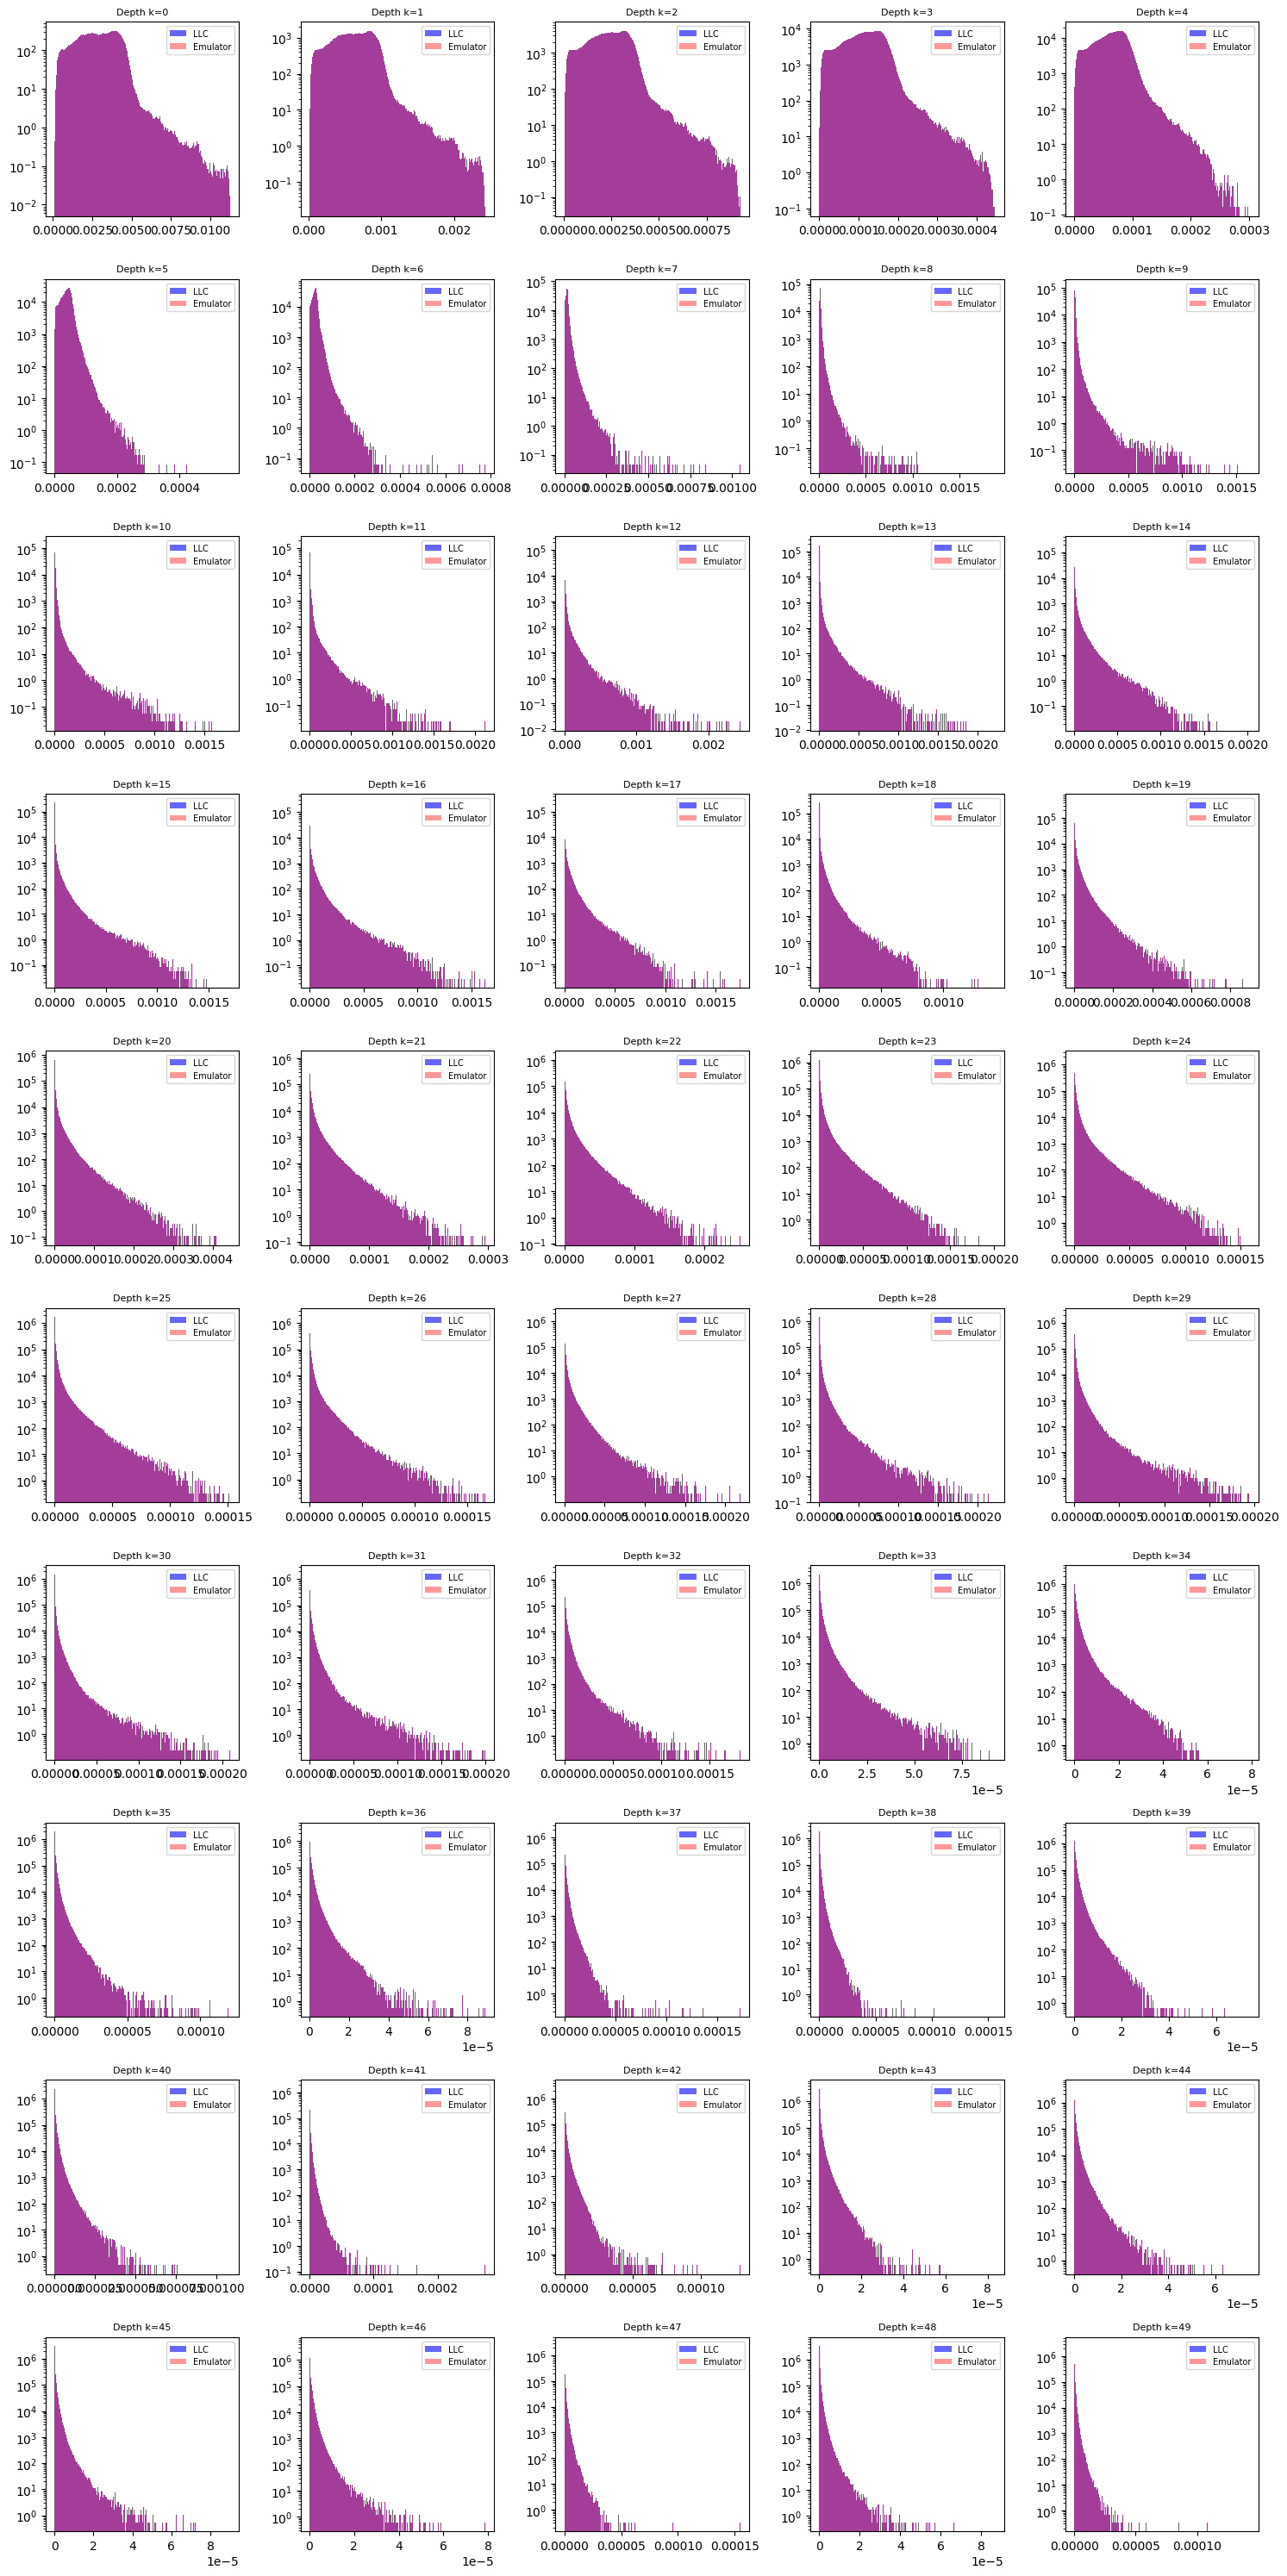

In [ ]:
n_depths = len(S2_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(S2_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(S2_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## Vorticity

In [21]:
omega = 7.2921e-5

# LLC Patch
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

vort_llc = ((np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2 - \
            (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2)

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]
vort_llc_normalized = np.clip(vort_llc_normalized, np.nanpercentile(vort_llc_normalized, 1), np.nanpercentile(vort_llc_normalized, 99))
vort_llc_normalized = vort_llc_normalized / np.nanmax(np.abs(vort_llc_normalized))

llc_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)

# Emulator Patch
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

vort_emulator = ((np.roll(emulator_patch['V'].values, -1, axis=3) - np.roll(emulator_patch['V'].values, 1, axis=3)) / 2 - \
                 (np.roll(emulator_patch['U'].values, -1, axis=2) - np.roll(emulator_patch['U'].values, 1, axis=2)) / 2)

vort_emulator_normalized = vort_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]
vort_emulator_normalized = np.clip(vort_emulator_normalized, np.nanpercentile(vort_emulator_normalized, 1), np.nanpercentile(vort_emulator_normalized, 99))
vort_emulator_normalized = vort_emulator_normalized / np.nanmax(np.abs(vort_emulator_normalized))

emulator_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_emulator_normalized)

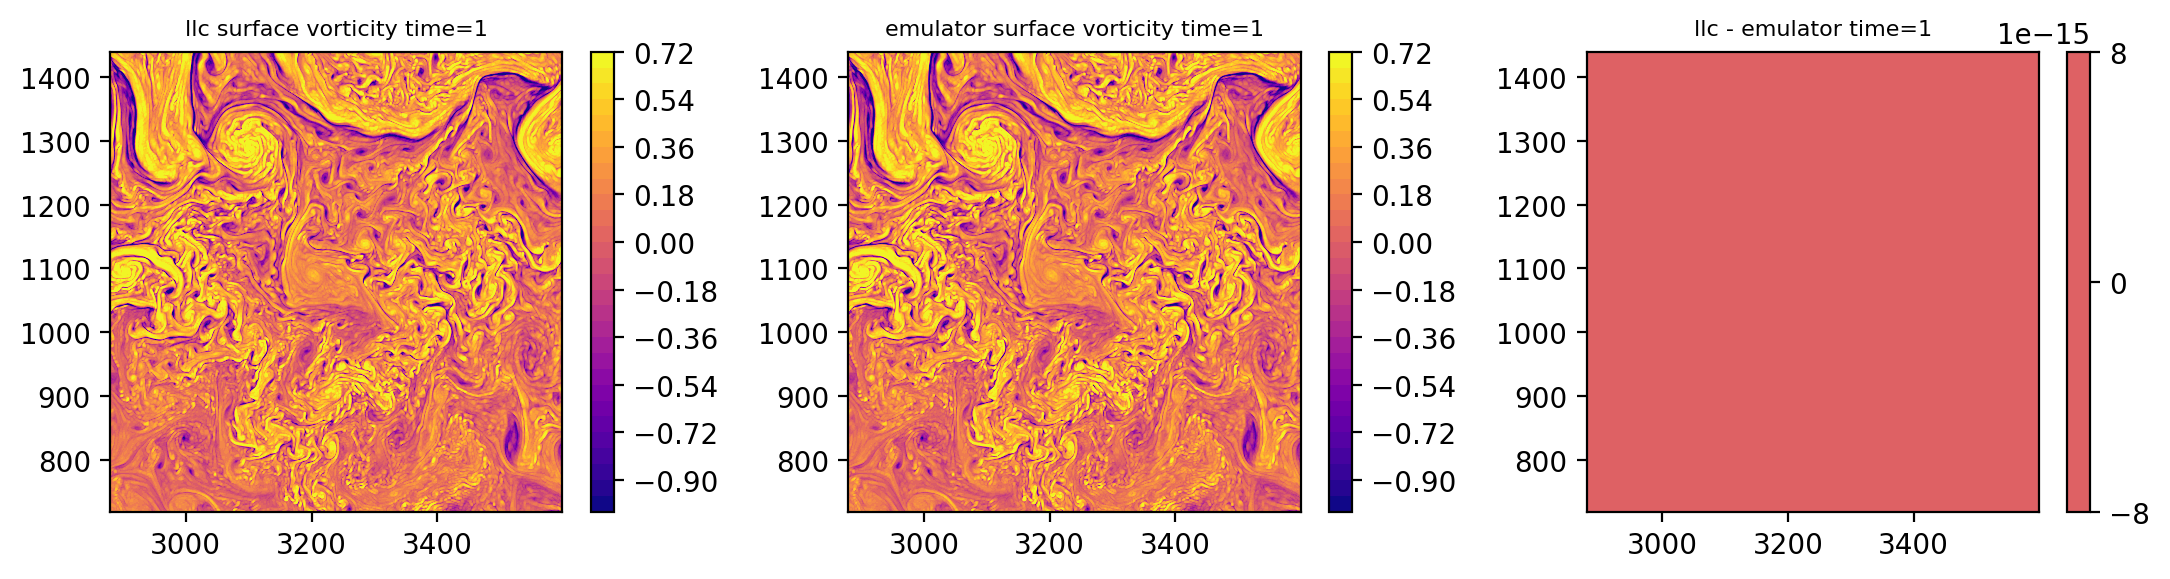

In [22]:
llc_vis = llc_patch.isel(time=1,k=0).vorticity
emulator_vis = emulator_patch.isel(time=1,k=0).vorticity

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=np.min(llc_vis).values,vmax=np.max(llc_vis).values, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface vorticity time=1', fontsize=8)

cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface vorticity time=1', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="plasma",vmin=np.min(emulator_vis).values,vmax=np.max(emulator_vis).values, levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=1', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
vort_hist_llc = llc_patch.vorticity.stack(vals=['time','i','j']).values
vort_hist_emulator = emulator_patch.vorticity.stack(vals=['time','i','j']).values

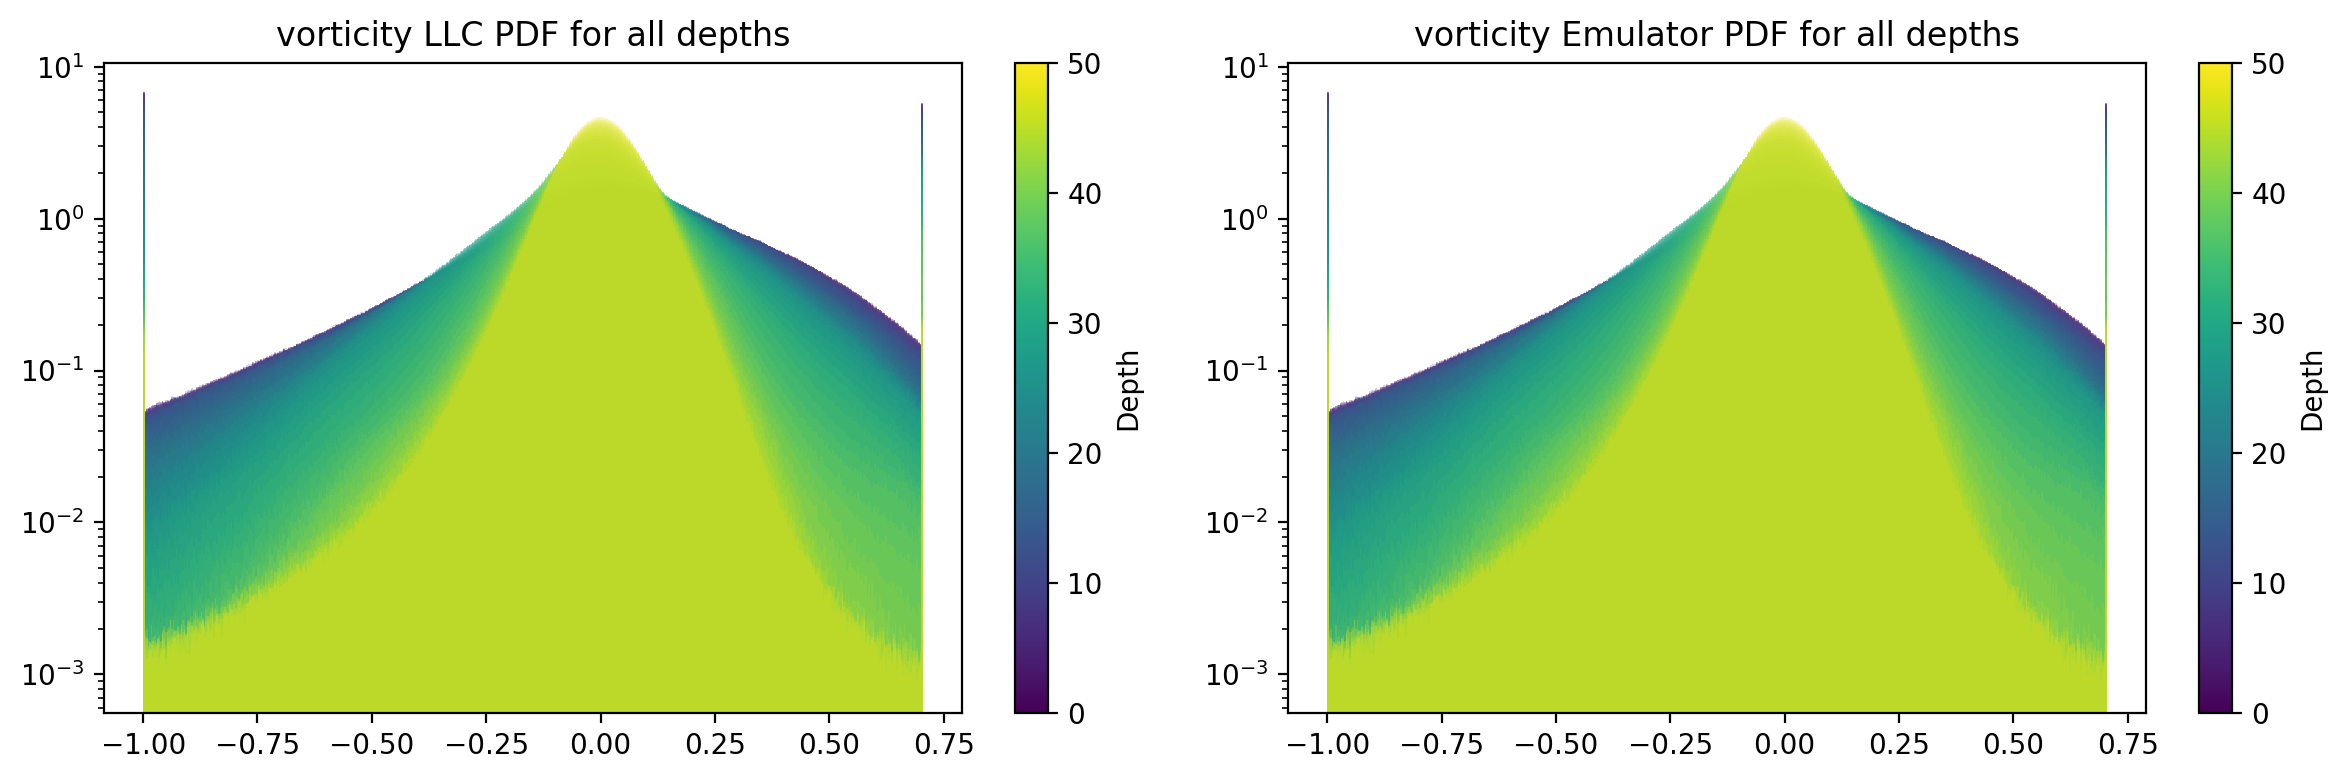

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=200)

cm = [plt.cm.viridis(i/len(vort_hist_llc)) for i in range(len(vort_hist_llc))]
for k in range(0,len(vort_hist_llc)):
    ax1.hist(vort_hist_llc[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(vort_hist_llc)-1))
sm.set_array([])
ax1.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax1)
ax1.set_title('vorticity LLC PDF for all depths')

cm = [plt.cm.viridis(i/len(vort_hist_emulator)) for i in range(len(vort_hist_emulator))]
for k in range(0,len(vort_hist_emulator)):
    ax2.hist(vort_hist_emulator[k],bins=500, density=True, color = cm[k],alpha=0.2)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0, vmax=len(vort_hist_emulator)-1))
sm.set_array([])
ax2.set_yscale('log')
plt.colorbar(sm, label='Depth', ax=ax2)
ax2.set_title('vorticity Emulator PDF for all depths')
plt.tight_layout()
plt.show()

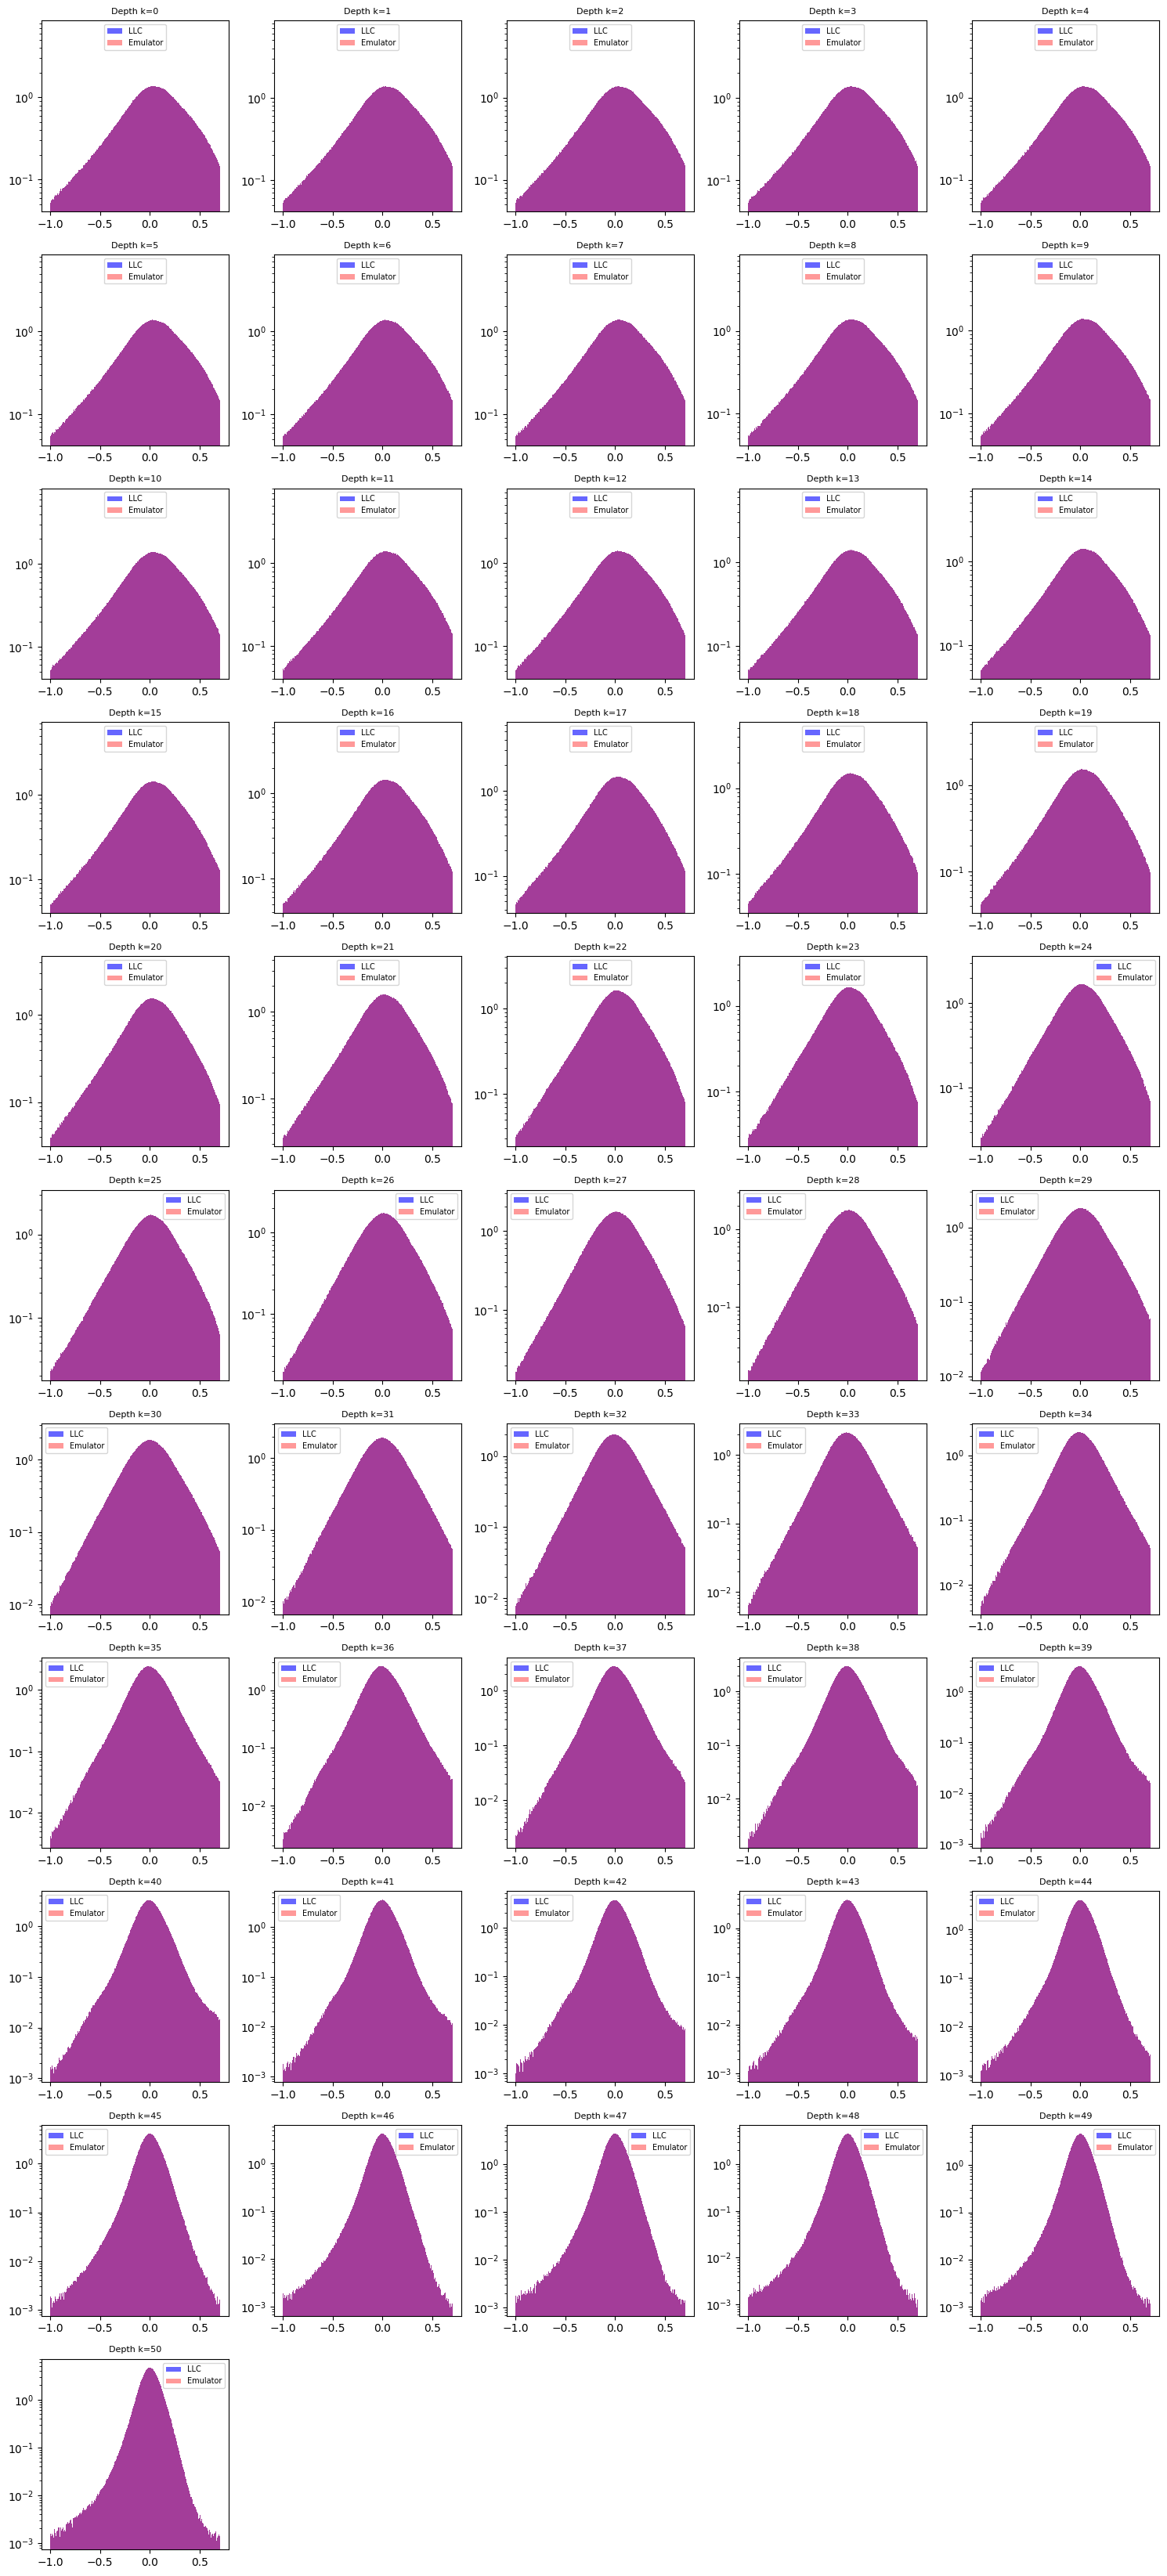

In [29]:
n_depths = len(vort_hist_llc)
ncols = 5
nrows = (n_depths + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3*nrows), dpi=100)
axes = axes.flatten()

for k in range(n_depths):
    ax = axes[k]
    ax.hist(vort_hist_llc[k], bins=500, density=True, color='blue', alpha=0.6, label='LLC')
    ax.hist(vort_hist_emulator[k], bins=500, density=True, color='red', alpha=0.4, label='Emulator')
    ax.set_title(f'Depth k={k}', fontsize=8)
    ax.set_yscale('log')
    ax.legend(fontsize=7)

# Hide unused subplots
for k in range(n_depths, len(axes)):
    axes[k].set_visible(False)

plt.tight_layout()
plt.show()

## W

In [ ]:
# omega = 7.2921e-5
# f_0 = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

# Z = llc_patch['Z'].values
# DEPTH_THICKNESS = np.abs(np.diff(Z))

# u_x = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
# v_y = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2
# divergence = u_x + v_y

# W_div = np.zeros_like(divergence)
# for k in range(divergence.shape[1] - 1, 0, -1):
#     W_div[:, k-1, :, :] = W_div[:, k, :, :] - divergence[:, k, :, :] * DEPTH_THICKNESS[k-1]

# W_div_normalized = W_div / f_0[np.newaxis, np.newaxis, :, :]
# W_div_normalized = np.clip(W_div_normalized, 
#                             np.nanpercentile(W_div_normalized, 1), 
#                             np.nanpercentile(W_div_normalized, 99))
# W_div_normalized = W_div_normalized / np.nanmax(np.abs(W_div_normalized))

# llc_patch['W_div'] = (('time', 'k', 'j', 'i'), W_div_normalized)

## Strain

In [ ]:
omega = 7.2921e-5
f_0 = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

u_x = (np.roll(llc_patch['U'].values, -1, axis=3) - np.roll(llc_patch['U'].values, 1, axis=3)) / 2
u_y = (np.roll(llc_patch['U'].values, -1, axis=2) - np.roll(llc_patch['U'].values, 1, axis=2)) / 2
v_x = (np.roll(llc_patch['V'].values, -1, axis=3) - np.roll(llc_patch['V'].values, 1, axis=3)) / 2
v_y = (np.roll(llc_patch['V'].values, -1, axis=2) - np.roll(llc_patch['V'].values, 1, axis=2)) / 2

sigma_n = u_x - v_y
sigma_s = v_x + u_y
sigma = np.sqrt(sigma_n**2 + sigma_s**2)

sigma_normalized = sigma / f_0[np.newaxis, np.newaxis, :, :]
sigma_normalized = sigma_normalized / np.nanmax(sigma_normalized)

llc_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_normalized)

## N2

In [ ]:
SA = llc_patch['Salt'].values * (35.16504 / 35)
CT = llc_patch['Theta'].values

g = 9.81
rho0 = 1025.0
alpha = 2e-4
beta = 7.4e-4

dT = np.diff(CT, axis=1)
dS = np.diff(SA, axis=1)
dz = np.diff(llc_patch.Z.values)
dz = dz[np.newaxis, :, np.newaxis, np.newaxis]

N2 = -(g / rho0) * (-alpha * rho0 * dT / dz + beta * rho0 * dS / dz)

llc_patch['N2'] = xr.DataArray(N2, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

## Ri

In [ ]:
Ri = N2 / (S2 + 1e-10)

llc_patch['Ri'] = xr.DataArray(Ri, dims=['time', 'k', 'j', 'i'], 
                                coords={'time': llc_patch['time'], 'k': llc_patch['k'][:-1],
                                        'j': llc_patch['j'], 'i': llc_patch['i']})

## T-S Plots